# ML Foundations — Notebook 3: Generalisation
## Build Fellowship Machine Vision Course

Notebook 2 showed you how a network learns.  
This notebook shows you how to tell whether it learned the **right thing**.

A model that memorises training data is useless in production.  
A model that generalises — capturing the true signal, not the noise — is what we're building toward.

---

### What we cover

| Section | Topic |
|---------|-------|
| 0 | Setup & shared utilities |
| 1 | The bias-variance decomposition — formal derivation |
| 2 | Visualising bias and variance experimentally |
| 3 | The double descent phenomenon |
| 4 | Regularisation — L2 (Ridge) from first principles |
| 5 | Regularisation — L1 (Lasso) and sparsity |
| 6 | Dropout — stochastic regularisation |
| 7 | Early stopping — regularisation through time |
| 8 | Ensemble methods — why averaging helps |
| 9 | Bagging — Bootstrap Aggregating, derived and implemented |
| 10 | Boosting — AdaBoost, derived and implemented |
| 11 | Bagging vs Boosting — when to use which |
| 12 | Putting it together — regularisation strategy for defect detection |

> Cells tagged `# 🔍 DERIVATION` work through math.  
> Cells tagged `# 🖼 PLOT` produce the figure above.  
> Cells tagged `# ⚙ IMPLEMENTATION` are working algorithms.


---
## Section 0 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression as SKLearnLR, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'lines.linewidth': 2.2,
})

C = {
    'blue':   '#1565C0', 'red':    '#C62828', 'orange': '#E65100',
    'green':  '#2E7D32', 'purple': '#6A1B9A', 'grey':   '#546E7A',
    'teal':   '#00695C', 'amber':  '#FF8F00', 'light':  '#ECEFF1',
}

def hline(ax, y, **kw): ax.axhline(y, color=C['grey'], ls='--', lw=1.2, alpha=0.6, **kw)
def vline(ax, x, **kw): ax.axvline(x, color=C['grey'], ls='--', lw=1.2, alpha=0.6, **kw)

print("✓ Setup complete")


✓ Setup complete


---
## Section 1 — The Bias-Variance Decomposition

### What we want to minimise

The **expected test error** of a model $\hat{f}$ trained on a random dataset $D$  
drawn from distribution $P(X, Y)$:

$$\mathbb{E}_{D}\left[(y - \hat{f}(x))^2\right]$$

### The decomposition

For a fixed test point $x$, with $y = f(x) + \epsilon$, $\epsilon \sim \mathcal{N}(0, \sigma^2)$:

$$\underbrace{\mathbb{E}_D\left[(y - \hat{f}(x))^2\right]}_{\text{Expected test error}}
= \underbrace{\left(\mathbb{E}_D[\hat{f}(x)] - f(x)\right)^2}_{\text{Bias}^2}
+ \underbrace{\mathbb{E}_D\left[\left(\hat{f}(x) - \mathbb{E}_D[\hat{f}(x)]\right)^2\right]}_{\text{Variance}}
+ \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

### Proof sketch

Let $\bar{f}(x) = \mathbb{E}_D[\hat{f}(x)]$ be the mean prediction across all training sets.

$$\mathbb{E}_D[(y - \hat{f})^2]
= \mathbb{E}_D[(y - \bar{f} + \bar{f} - \hat{f})^2]$$

Expanding and noting that $\mathbb{E}_D[\bar{f} - \hat{f}] = 0$ (the cross-term vanishes):

$$= (y - \bar{f})^2 + \mathbb{E}_D[(\hat{f} - \bar{f})^2]$$

Substituting $y = f(x) + \epsilon$ and taking expectation over $\epsilon$:

$$= \underbrace{(\bar{f} - f(x))^2}_{\text{Bias}^2}
+ \underbrace{\mathbb{E}_D[(\hat{f} - \bar{f})^2]}_{\text{Variance}}
+ \underbrace{\sigma^2}_{\text{Noise}}$$

### What each term means

| Term | Meaning | Caused by | Fixed by |
|------|---------|-----------|----------|
| **Bias²** | How wrong is the average prediction? | Model too simple, wrong assumptions | More capacity, better architecture |
| **Variance** | How much does the prediction vary with training data? | Model too complex, too sensitive to data | Regularisation, more data, ensembles |
| **Noise** | Irreducible error from the data itself | Data labelling error, inherent stochasticity | Nothing — it is a floor |


In [2]:
# 🔍 DERIVATION — Numerically verify the decomposition

def true_function(x):
    return 0.8 * np.sin(2.5 * x) + 0.3 * x

noise_std = 0.3
n_train   = 25
n_test    = 500
n_trials  = 200    # number of different training sets

np.random.seed(SEED)
x_test = np.linspace(-2, 2, n_test)
f_true = true_function(x_test)

# Fit polynomial models of different degrees on many training sets
degrees = [1, 3, 8, 15]
results = {}

for deg in degrees:
    preds_on_test = []
    for trial in range(n_trials):
        # Sample a fresh training set
        x_tr = np.random.uniform(-2, 2, n_train)
        y_tr = true_function(x_tr) + np.random.randn(n_train) * noise_std

        # Fit polynomial
        pipe = Pipeline([
            ('poly', PolynomialFeatures(degree=deg, include_bias=True)),
            ('scaler', StandardScaler()),
            ('lr', Ridge(alpha=1e-6)),  # high C = minimal regularisation
        ])
        pipe.fit(x_tr.reshape(-1,1), y_tr)
        y_pred = pipe.predict(x_test.reshape(-1,1))
        preds_on_test.append(y_pred)

    preds  = np.array(preds_on_test)          # shape (n_trials, n_test)
    f_bar  = preds.mean(axis=0)               # mean prediction across trials
    bias2  = np.mean((f_bar - f_true)**2)
    variance = np.mean(np.var(preds, axis=0))
    mse_expected = np.mean((preds - f_true[None,:])**2)

    results[deg] = {
        'preds':    preds,
        'f_bar':    f_bar,
        'bias2':    bias2,
        'variance': variance,
        'noise':    noise_std**2,
        'total':    mse_expected,
        'sum_check': bias2 + variance + noise_std**2,
    }

print(f"{'Degree':>8} {'Bias²':>10} {'Variance':>10} {'Noise':>8} "
      f"{'Bias²+Var+Noise':>18} {'Actual MSE':>12}")
print("-" * 72)
for deg, r in results.items():
    print(f"  deg={deg:>2}  {r['bias2']:>10.4f} {r['variance']:>10.4f} "
          f"{r['noise']:>8.4f} {r['sum_check']:>18.4f} {r['total']:>12.4f}")

print()
print("Bias² + Variance + Noise ≈ Actual MSE  ✓  (small discrepancy from finite trials)")
print()
print("Observations:")
print("  deg=1  : high bias  (underfit), low variance  → model too simple")
print("  deg=3  : low bias,  low variance  → good balance")
print("  deg=8  : low bias,  higher variance  → starting to overfit")
print("  deg=15 : low bias,  very high variance  → severe overfit")


  Degree      Bias²   Variance    Noise    Bias²+Var+Noise   Actual MSE
------------------------------------------------------------------------
  deg= 1      0.3202     0.0316   0.0900             0.4418       0.3518
  deg= 3      0.0876     0.0551   0.0900             0.2326       0.1426
  deg= 8      0.0734     8.9313   0.0900             9.0947       9.0047
  deg=15      3.8378  1402.7749   0.0900          1406.7027    1406.6127

Bias² + Variance + Noise ≈ Actual MSE  ✓  (small discrepancy from finite trials)

Observations:
  deg=1  : high bias  (underfit), low variance  → model too simple
  deg=3  : low bias,  low variance  → good balance
  deg=8  : low bias,  higher variance  → starting to overfit
  deg=15 : low bias,  very high variance  → severe overfit


---
## Section 2 — Visualising Bias and Variance Experimentally

The key visual: run the same model on many different training sets.

- **High bias** models produce predictions that are **wrong in the same way** every time —
  the mean prediction is systematically off from the truth.
- **High variance** models produce predictions that **scatter widely** across training sets —
  each run gives a very different curve.


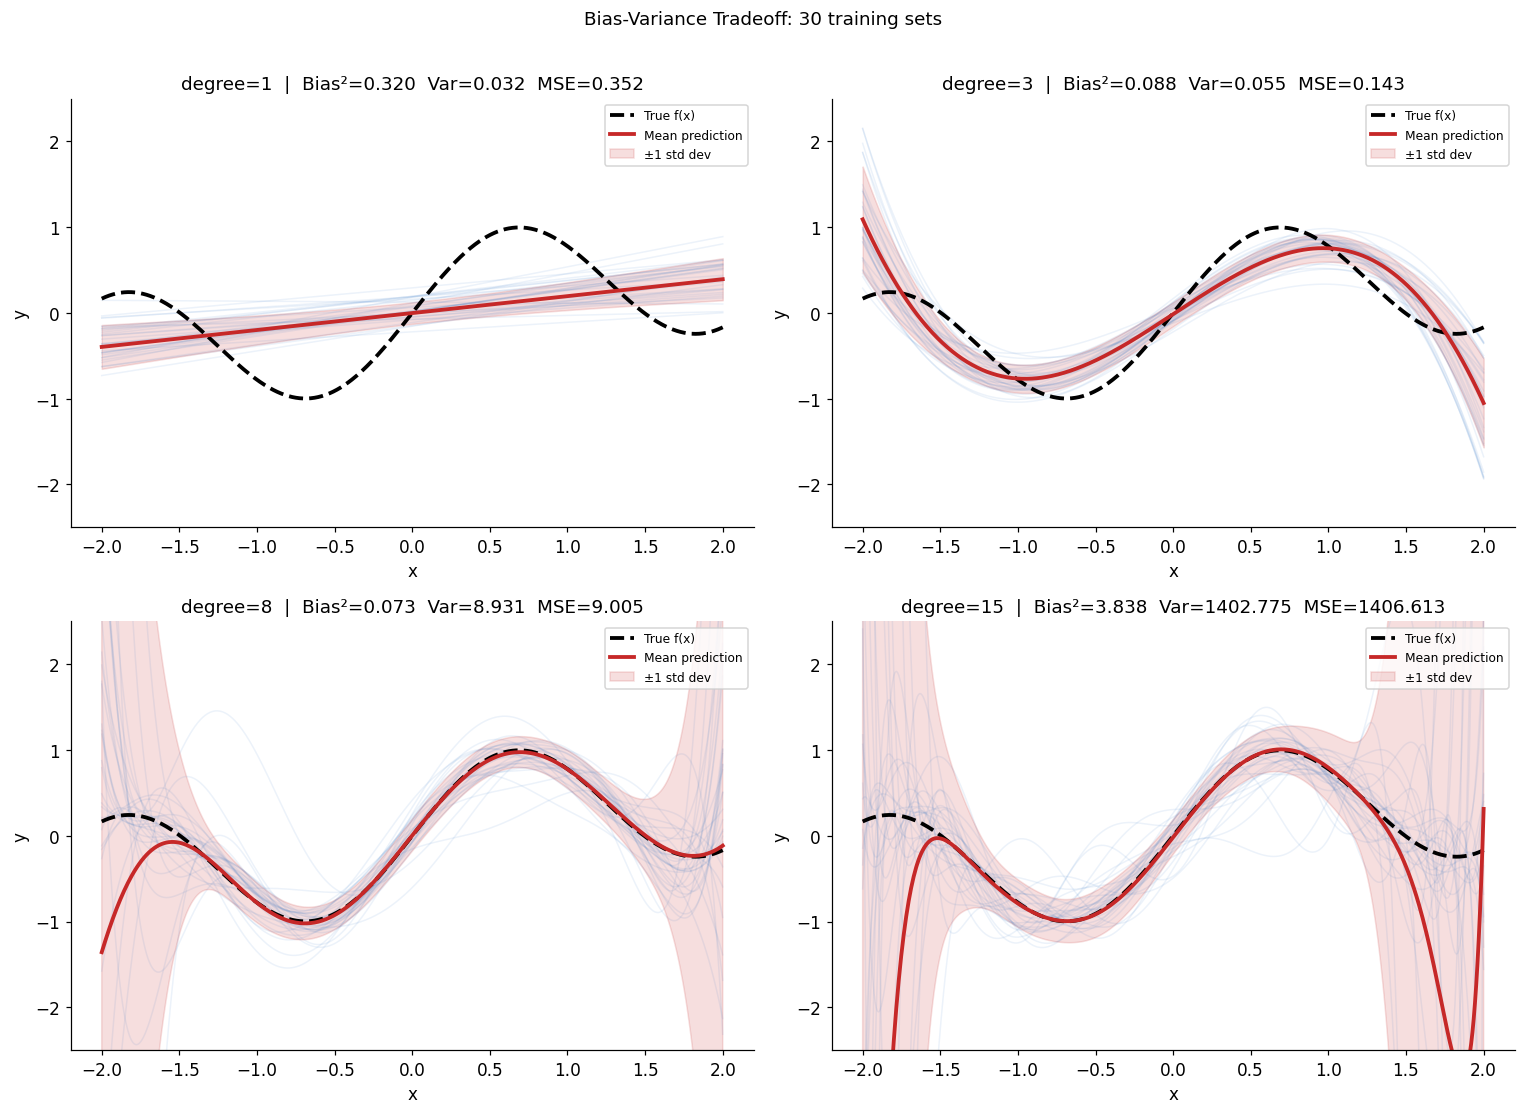

In [3]:
# 🖼 PLOT — Prediction spread across 200 training sets, 4 model complexities

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, deg in zip(axes, degrees):
    r = results[deg]
    # Show a random subset of individual fits
    for i in range(min(30, len(r['preds']))):
        ax.plot(x_test, r['preds'][i], color=C['blue'], alpha=0.08, lw=1)

    ax.plot(x_test, f_true,  color='black',     lw=2.5, ls='--', label='True f(x)')
    ax.plot(x_test, r['f_bar'], color=C['red'],  lw=2.5,          label='Mean prediction')

    # Shade variance band
    std_pred = r['preds'].std(axis=0)
    ax.fill_between(x_test, r['f_bar'] - std_pred, r['f_bar'] + std_pred,
                    color=C['red'], alpha=0.15, label='±1 std dev')

    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'degree={deg}  |  Bias²={r["bias2"]:.3f}  '
                 f'Var={r["variance"]:.3f}  MSE={r["total"]:.3f}')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Bias-Variance Tradeoff: 30 training sets',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


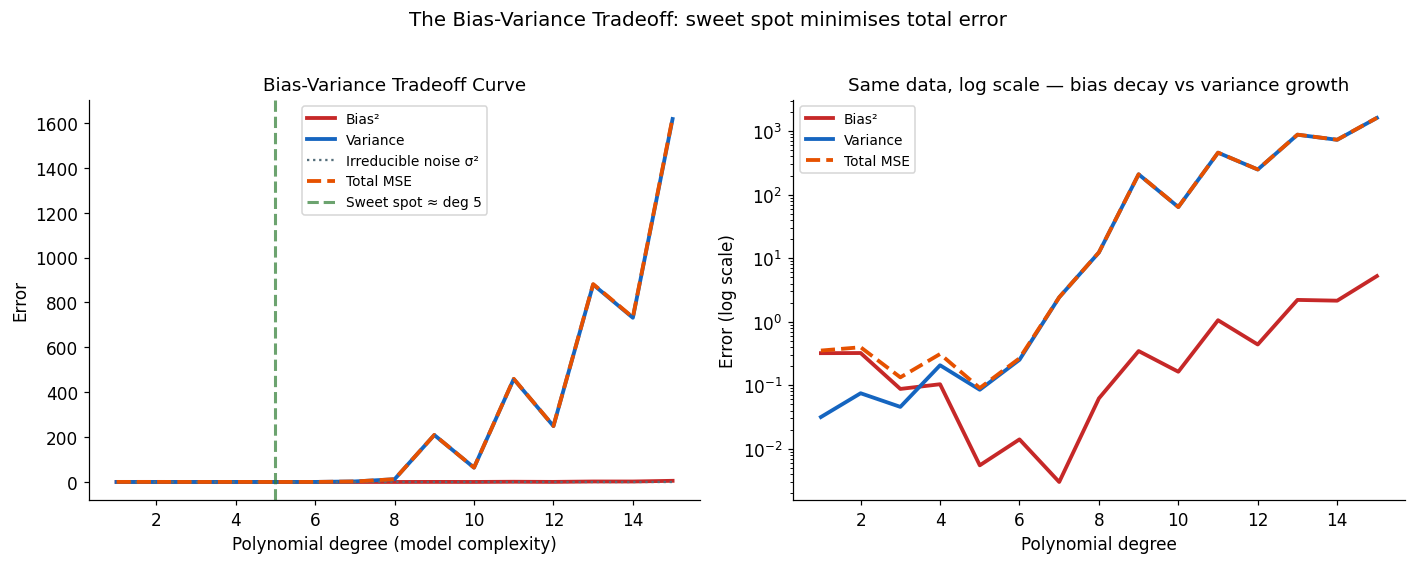

Optimal degree (min total MSE): 5
  Bias²    at optimum: 0.0055
  Variance at optimum: 0.0850
  Total    at optimum: 0.0905


In [4]:
# 🖼 PLOT — Bias², Variance, and Total Error vs model complexity

deg_fine  = list(range(1, 16))
bias2s, variances, totals = [], [], []

for deg in deg_fine:
    preds_all = []
    np.random.seed(SEED)
    for _ in range(n_trials):
        x_tr = np.random.uniform(-2, 2, n_train)
        y_tr = true_function(x_tr) + np.random.randn(n_train)*noise_std
        pipe = Pipeline([('poly', PolynomialFeatures(deg, include_bias=True)),
                         ('sc', StandardScaler()),
                         ('lr', Ridge(alpha=1e-6))])
        pipe.fit(x_tr.reshape(-1,1), y_tr)
        preds_all.append(pipe.predict(x_test.reshape(-1,1)))
    preds_all = np.array(preds_all)
    f_bar_d   = preds_all.mean(axis=0)
    bias2s.append(np.mean((f_bar_d - f_true)**2))
    variances.append(np.mean(np.var(preds_all, axis=0)))
    totals.append(np.mean((preds_all - f_true)**2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(deg_fine, bias2s,    color=C['red'],    label='Bias²',    lw=2.5)
ax.plot(deg_fine, variances, color=C['blue'],   label='Variance', lw=2.5)
ax.plot(deg_fine, [noise_std**2]*len(deg_fine), color=C['grey'],
        ls=':', lw=1.5, label='Irreducible noise σ²')
ax.plot(deg_fine, totals,    color=C['orange'], label='Total MSE', lw=2.5, ls='--')
ax.set_xlabel('Polynomial degree (model complexity)')
ax.set_ylabel('Error')
ax.set_title('Bias-Variance Tradeoff Curve')
ax.legend()

# Mark sweet spot
sweet = deg_fine[np.argmin(totals)]
ax.axvline(sweet, color=C['green'], ls='--', lw=2, alpha=0.7,
           label=f'Sweet spot ≈ deg {sweet}')
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(deg_fine, bias2s,    color=C['red'],    label='Bias²',    lw=2.5)
ax.semilogy(deg_fine, variances, color=C['blue'],   label='Variance', lw=2.5)
ax.semilogy(deg_fine, totals,    color=C['orange'], label='Total MSE', lw=2.5, ls='--')
ax.set_xlabel('Polynomial degree')
ax.set_ylabel('Error (log scale)')
ax.set_title('Same data, log scale — bias decay vs variance growth')
ax.legend(fontsize=9)

plt.suptitle('The Bias-Variance Tradeoff: sweet spot minimises total error',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Optimal degree (min total MSE): {sweet}")
print(f"  Bias²    at optimum: {bias2s[sweet-1]:.4f}")
print(f"  Variance at optimum: {variances[sweet-1]:.4f}")
print(f"  Total    at optimum: {totals[sweet-1]:.4f}")


---
## Section 3 — The Double Descent Phenomenon

Classical theory predicts a single U-shaped test error curve.  
Modern neural networks violate this: beyond the interpolation threshold,  
**test error decreases again** as model capacity continues to grow.

This is called **double descent** and was formally described by Belkin et al. (2019).

### Why it happens

When a model has just enough capacity to fit the training data exactly  
(the **interpolation threshold**), it is forced to fit noise — the worst case.  
When it has *more* than enough capacity, there are many solutions that fit the data;  
the implicit regularisation of gradient descent tends to find smoother,  
better-generalising ones among these.

This explains why modern over-parameterised networks (billions of parameters  
trained on millions of examples) generalise far better than classical theory  
would predict.

> **Note:** Double descent is observed primarily for neural networks trained with SGD.  
> The demonstration below uses a polynomial model to show the transition region  
> — the key shape is the same.


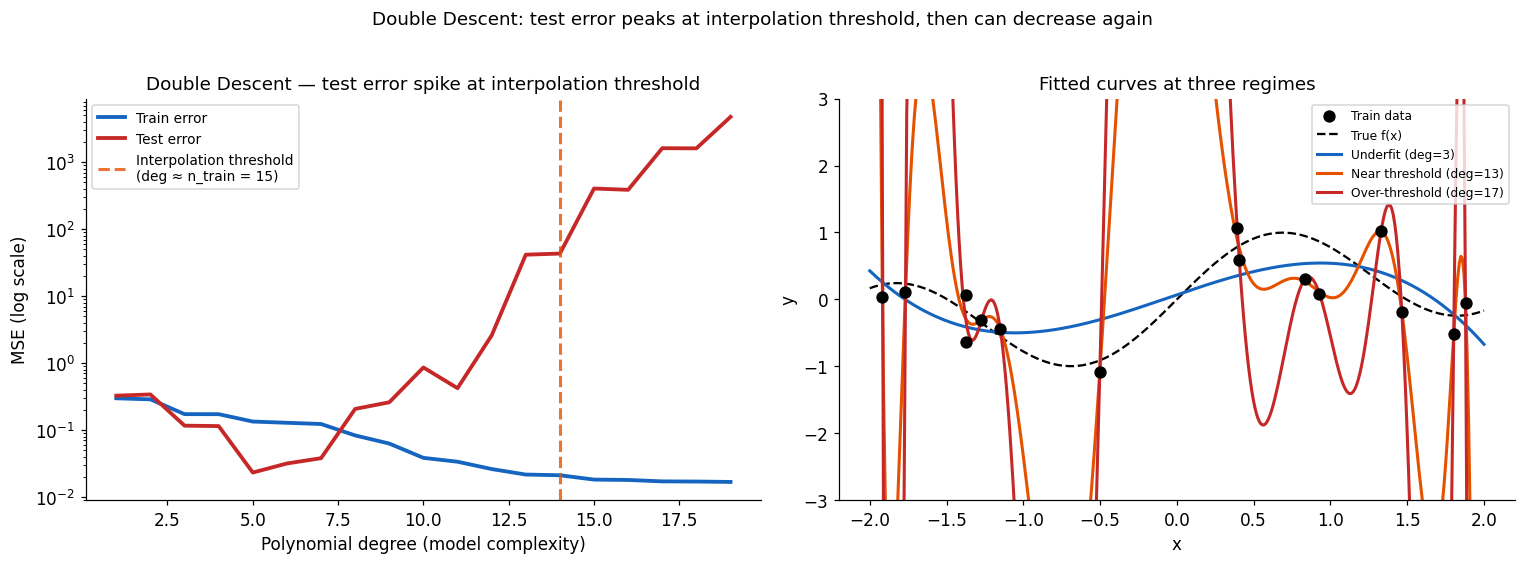

In [5]:
# 🖼 PLOT — Double-descent shaped curve (polynomial interpolation regime)
# We increase polynomial degree past interpolation threshold

np.random.seed(SEED)
n_small   = 15       # intentionally small to see interpolation threshold
x_dd      = np.random.uniform(-2, 2, n_small)
y_dd      = true_function(x_dd) + np.random.randn(n_small) * noise_std

x_test_dd = np.linspace(-2, 2, 400)
f_true_dd = true_function(x_test_dd)

train_errs, test_errs = [], []
degrees_dd = list(range(1, n_small + 5))

for deg in degrees_dd:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(deg, include_bias=True)),
        ('sc',   StandardScaler()),
        ('lr',   Ridge(alpha=1e-10)),  # nearly zero regularisation
    ])
    pipe.fit(x_dd.reshape(-1,1), y_dd)
    tr_pred  = pipe.predict(x_dd.reshape(-1,1))
    te_pred  = pipe.predict(x_test_dd.reshape(-1,1))
    train_errs.append(np.mean((tr_pred - y_dd)**2))
    test_errs.append(np.mean((te_pred - f_true_dd)**2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(degrees_dd, train_errs, color=C['blue'],   lw=2.5, label='Train error')
ax.semilogy(degrees_dd, test_errs,  color=C['red'],    lw=2.5, label='Test error')
ax.axvline(n_small - 1, color=C['orange'], ls='--', lw=2, alpha=0.8,
           label=f'Interpolation threshold\n(deg ≈ n_train = {n_small})')
ax.set_xlabel('Polynomial degree (model complexity)')
ax.set_ylabel('MSE (log scale)')
ax.set_title('Double Descent — test error spike at interpolation threshold')
ax.legend(fontsize=9)

# Show the fit at different regimes
ax = axes[1]
ax.scatter(x_dd, y_dd, s=50, color='black', zorder=5, label='Train data')
ax.plot(x_test_dd, f_true_dd, 'k--', lw=1.5, label='True f(x)')
regimes = [
    (3,           C['blue'],   'Underfit (deg=3)'),
    (n_small - 2, C['orange'], f'Near threshold (deg={n_small-2})'),
    (n_small + 2, C['red'],    f'Over-threshold (deg={n_small+2})'),
]
for deg, col, lbl in regimes:
    if deg in degrees_dd:
        pipe = Pipeline([('poly', PolynomialFeatures(deg, include_bias=True)),
                         ('sc', StandardScaler()),
                         ('lr', Ridge(alpha=1e-10))])
        pipe.fit(x_dd.reshape(-1,1), y_dd)
        ax.plot(x_test_dd,
                np.clip(pipe.predict(x_test_dd.reshape(-1,1)), -4, 4),
                color=col, lw=2, label=lbl)

ax.set_ylim(-3, 3)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Fitted curves at three regimes')
ax.legend(fontsize=8)

plt.suptitle('Double Descent: test error peaks at interpolation threshold, '
             'then can decrease again', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 4 — Regularisation: L2 (Ridge) from First Principles

### The idea

Add a penalty term to the loss that discourages large weights:

$$\mathcal{L}_{\text{reg}} = \mathcal{L}_{\text{data}} + \lambda \|\mathbf{w}\|_2^2
= \mathcal{L}_{\text{data}} + \lambda \sum_j w_j^2$$

$\lambda$ is the **regularisation strength** — how much we penalise large weights.

### Effect on the gradient

$$\frac{\partial \mathcal{L}_{\text{reg}}}{\partial w_j}
= \frac{\partial \mathcal{L}_{\text{data}}}{\partial w_j} + 2\lambda w_j$$

The update rule becomes:

$$w_j \leftarrow w_j - \eta \left(\frac{\partial \mathcal{L}_{\text{data}}}{\partial w_j} + 2\lambda w_j\right)
= (1 - 2\eta\lambda)w_j - \eta \frac{\partial \mathcal{L}_{\text{data}}}{\partial w_j}$$

The factor $(1 - 2\eta\lambda)$ **shrinks** the weight toward zero at every step.  
This is called **weight decay** — the PyTorch equivalent is `optimizer = SGD(..., weight_decay=λ)`.

### Why it reduces variance

Restricting the magnitude of weights limits how dramatically the model can change  
in response to individual training points — directly reducing variance.  
It is equivalent to placing a Gaussian prior on the weights (Bayesian interpretation).


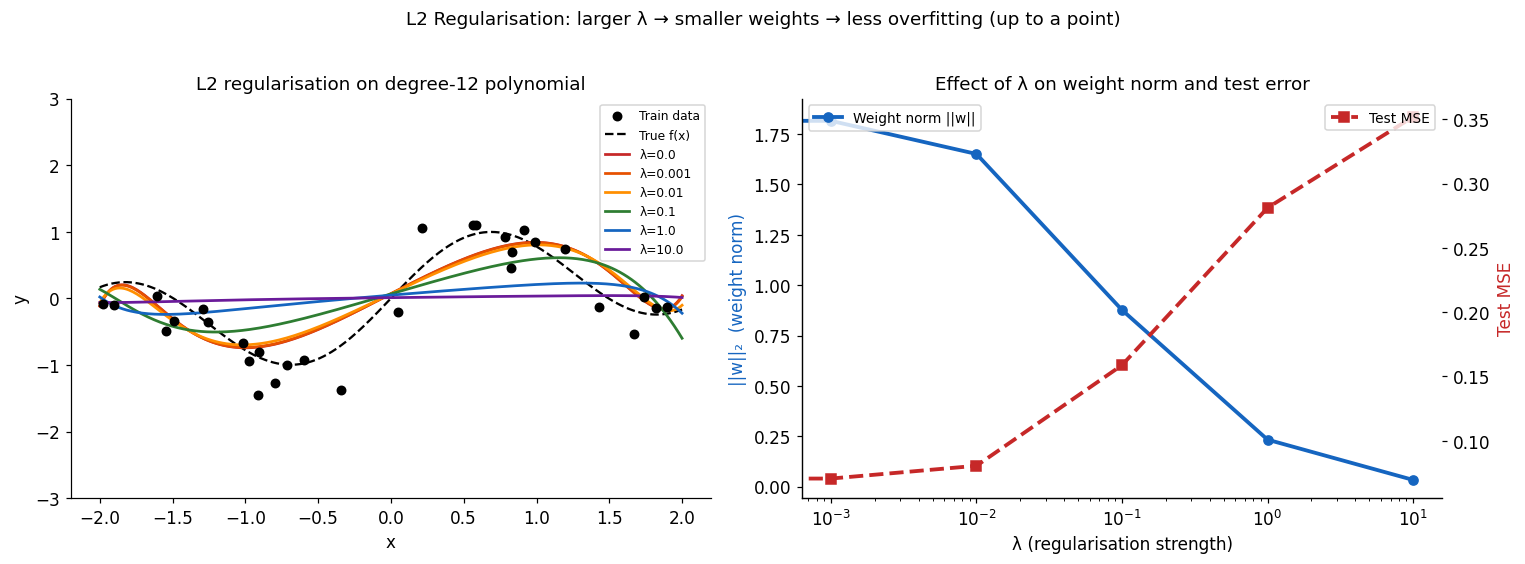

Best λ: 0.0 → Test MSE = 0.0696
No reg λ=0 → Test MSE = 0.0696
Improvement from regularisation: 0.0%


In [6]:
# ⚙ IMPLEMENTATION — L2 regularised polynomial regression from scratch

def ridge_gradient_descent(X, y, lam=0.1, lr=0.01, n_iters=2000):
    """
    MSE + L2 penalty, full GD.
    dL/dw = (2/N) Xᵀ(Xw - y) + 2λw
    """
    n, d = X.shape
    w = np.random.randn(d) * 0.1
    losses = []
    for _ in range(n_iters):
        y_hat     = X @ w
        residuals = y_hat - y
        # Data gradient
        dL_data   = 2 * X.T @ residuals / n
        # Regularisation gradient
        dL_reg    = 2 * lam * w
        w         = w - lr * (dL_data + dL_reg)
        loss      = np.mean(residuals**2) + lam * np.dot(w, w)
        losses.append(loss)
    return w, losses


# Dataset
np.random.seed(SEED + 5)
n_reg      = 30
x_reg      = np.random.uniform(-2, 2, n_reg)
y_reg      = true_function(x_reg) + np.random.randn(n_reg) * noise_std
x_reg_test = np.linspace(-2, 2, 300)

# High-degree features to show regularisation effect
deg_r  = 12
scaler_r = StandardScaler()
X_reg  = PolynomialFeatures(deg_r, include_bias=False).fit_transform(x_reg.reshape(-1,1))
X_reg  = scaler_r.fit_transform(X_reg)
X_test_r = PolynomialFeatures(deg_r, include_bias=False).fit_transform(x_reg_test.reshape(-1,1))
X_test_r = scaler_r.transform(X_test_r)

lambdas  = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]
lam_cols = [C['red'], C['orange'], C['amber'], C['green'], C['blue'], C['purple']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(x_reg, y_reg, s=30, color='black', zorder=5, label='Train data')
ax.plot(x_reg_test, true_function(x_reg_test), 'k--', lw=1.5, label='True f(x)')

weight_norms = []
test_mses    = []

for lam, col in zip(lambdas, lam_cols):
    np.random.seed(SEED)
    w_fit, _ = ridge_gradient_descent(X_reg, y_reg, lam=lam, lr=0.005, n_iters=3000)
    y_pred_test = X_test_r @ w_fit
    weight_norms.append(np.linalg.norm(w_fit))
    test_mses.append(np.mean((y_pred_test - true_function(x_reg_test))**2))
    ax.plot(x_reg_test, np.clip(y_pred_test, -3, 3), color=col, lw=1.8,
            label=f'λ={lam}')

ax.set_ylim(-3, 3)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'L2 regularisation on degree-{deg_r} polynomial')
ax.legend(fontsize=8, loc='upper right')

ax = axes[1]
ax2 = ax.twinx()
ax.semilogx(lambdas, weight_norms, 'o-', color=C['blue'],  lw=2.5,
            label='Weight norm ||w||')
ax2.semilogx(lambdas, test_mses,   's--', color=C['red'],  lw=2.5,
             label='Test MSE')
ax.set_xlabel('λ (regularisation strength)')
ax.set_ylabel('||w||₂  (weight norm)', color=C['blue'])
ax2.set_ylabel('Test MSE', color=C['red'])
ax.set_title('Effect of λ on weight norm and test error')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('L2 Regularisation: larger λ → smaller weights → less overfitting (up to a point)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

best_lam_idx = np.argmin(test_mses)
print(f"Best λ: {lambdas[best_lam_idx]} → Test MSE = {test_mses[best_lam_idx]:.4f}")
print(f"No reg λ=0 → Test MSE = {test_mses[0]:.4f}")
print(f"Improvement from regularisation: {(test_mses[0]-test_mses[best_lam_idx])/test_mses[0]*100:.1f}%")


---
## Section 5 — L1 Regularisation and Sparsity

L1 adds the sum of **absolute values** of weights instead:

$$\mathcal{L}_{\text{L1}} = \mathcal{L}_{\text{data}} + \lambda \|\mathbf{w}\|_1
= \mathcal{L}_{\text{data}} + \lambda \sum_j |w_j|$$

### Gradient of L1

$$\frac{\partial |w_j|}{\partial w_j} = \text{sign}(w_j)$$

The update:

$$w_j \leftarrow w_j - \eta \left(\frac{\partial \mathcal{L}_{\text{data}}}{\partial w_j} + \lambda \cdot \text{sign}(w_j)\right)$$

### Why L1 produces sparse solutions

The L1 penalty pulls weights toward zero with a **constant force** $\lambda$, regardless of their magnitude.  
Small weights get pulled all the way to **exactly zero**.  
L2, by contrast, pulls with force proportional to $|w|$, so small weights shrink but rarely hit zero.

This means L1 performs **automatic feature selection** — irrelevant features get zero weight.  
For defect detection with hundreds of engineered features, L1 is a natural first step.


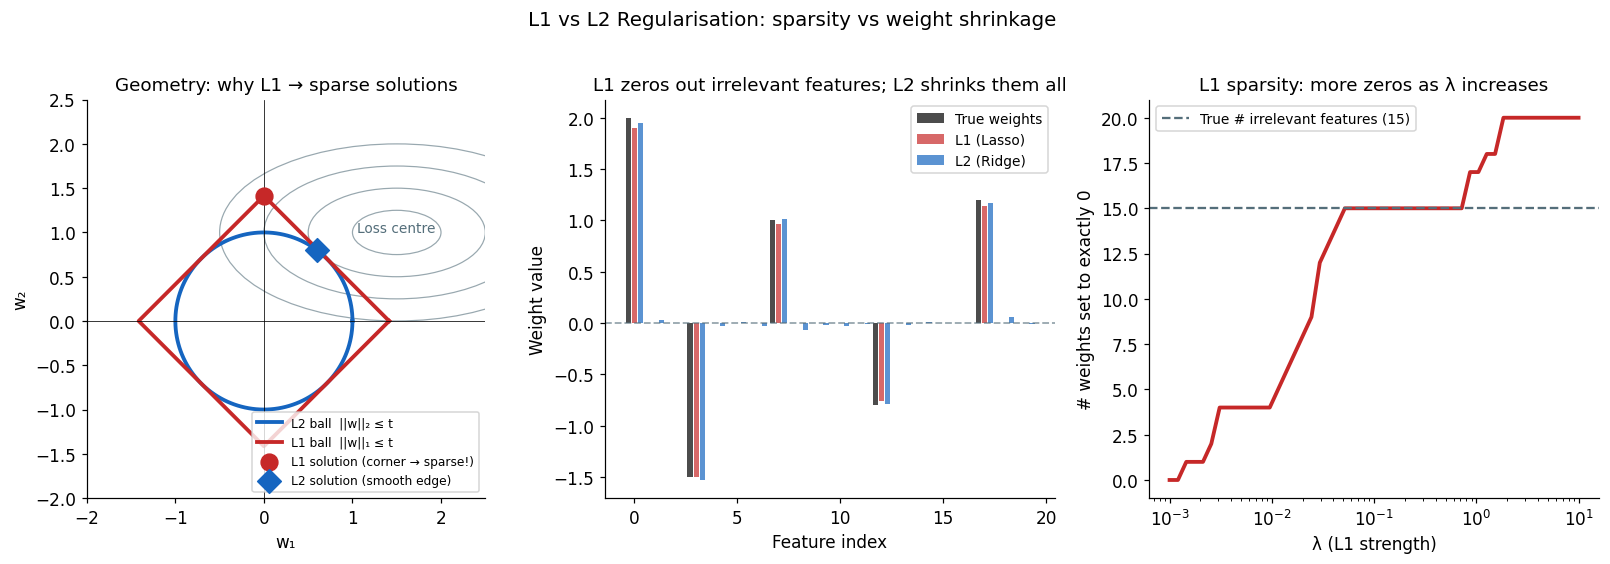

L1: 15/20 weights exactly zero
L2: 0/20 weights exactly zero

L1 correctly identifies sparse signal; L2 keeps all features but shrinks them.


In [7]:
# 🖼 PLOT — Geometric interpretation: L1 and L2 constraint regions

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

theta = np.linspace(0, 2*np.pi, 300)

# Panel 1: constraint geometry
ax = axes[0]
# L2 ball (circle)
ax.plot(np.cos(theta), np.sin(theta), color=C['blue'], lw=2.5, label='L2 ball  ||w||₂ ≤ t')
# L1 ball (diamond)
t_l1 = np.sqrt(2)
l1_x = np.array([t_l1, 0, -t_l1, 0, t_l1])
l1_y = np.array([0, t_l1, 0, -t_l1, 0])
ax.plot(l1_x, l1_y, color=C['red'], lw=2.5, label='L1 ball  ||w||₁ ≤ t')

# Elliptical loss contours
for r in [0.5, 1.0, 1.5, 2.0]:
    ax.add_patch(plt.matplotlib.patches.Ellipse((1.5, 1.0), 2*r, r,
                 fill=False, color=C['grey'], lw=0.8, alpha=0.6))
ax.text(1.5, 1.0, 'Loss centre', ha='center', fontsize=9, color=C['grey'])

# L1 touches at corner → sparse solution
ax.scatter([0], [t_l1], s=120, color=C['red'], zorder=5,
           label='L1 solution (corner → sparse!)')
# L2 touches on curve → non-sparse
ax.scatter([0.6], [0.8], s=120, color=C['blue'], zorder=5, marker='D',
           label='L2 solution (smooth edge)')

ax.set_xlim(-2, 2.5); ax.set_ylim(-2, 2.5)
ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
ax.set_title('Geometry: why L1 → sparse solutions')
ax.axhline(0, color='black', lw=0.5); ax.axvline(0, color='black', lw=0.5)
ax.legend(fontsize=8, loc='lower right')
ax.set_aspect('equal')

# Panel 2: weights under L1 vs L2
np.random.seed(SEED)
n_feat = 20
X_sp = np.random.randn(100, n_feat)
# Only 5 features are truly informative
true_w = np.zeros(n_feat)
true_w[[0, 3, 7, 12, 17]] = [2.0, -1.5, 1.0, -0.8, 1.2]
y_sp = X_sp @ true_w + np.random.randn(100) * 0.3

lasso  = Lasso(alpha=0.05,  max_iter=5000).fit(X_sp, y_sp)
ridge  = Ridge(alpha=0.5).fit(X_sp, y_sp)

ax = axes[1]
x_bar = np.arange(n_feat)
ax.bar(x_bar - 0.3, true_w,        0.25, color='black', alpha=0.7, label='True weights')
ax.bar(x_bar,       lasso.coef_,   0.25, color=C['red'],   alpha=0.7, label='L1 (Lasso)')
ax.bar(x_bar + 0.3, ridge.coef_,   0.25, color=C['blue'],  alpha=0.7, label='L2 (Ridge)')
hline(ax, 0)
ax.set_xlabel('Feature index'); ax.set_ylabel('Weight value')
ax.set_title('L1 zeros out irrelevant features; L2 shrinks them all')
ax.legend(fontsize=9)

# Panel 3: sparsity count vs lambda
lambdas_l1 = np.logspace(-3, 1, 50)
n_zeros = []
for lam in lambdas_l1:
    las = Lasso(alpha=lam, max_iter=5000).fit(X_sp, y_sp)
    n_zeros.append(np.sum(np.abs(las.coef_) < 1e-6))

ax = axes[2]
ax.semilogx(lambdas_l1, n_zeros, color=C['red'], lw=2.5)
ax.axhline(15, color=C['grey'], ls='--', lw=1.5, label='True # irrelevant features (15)')
ax.set_xlabel('λ (L1 strength)'); ax.set_ylabel('# weights set to exactly 0')
ax.set_title('L1 sparsity: more zeros as λ increases')
ax.legend(fontsize=9)

plt.suptitle('L1 vs L2 Regularisation: sparsity vs weight shrinkage',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"L1: {np.sum(np.abs(lasso.coef_) < 1e-6)}/{n_feat} weights exactly zero")
print(f"L2: {np.sum(np.abs(ridge.coef_) < 1e-6)}/{n_feat} weights exactly zero")
print()
print("L1 correctly identifies sparse signal; L2 keeps all features but shrinks them.")


---
## Section 6 — Dropout: Stochastic Regularisation

Dropout (Srivastava et al., 2014) randomly sets a fraction $p$ of neuron activations  
to zero during each **training** forward pass.

### How it works

During training, at each forward pass, independently zero each activation with probability $p$:

$$\tilde{a}_j = \frac{a_j \cdot m_j}{1 - p}, \qquad m_j \sim \text{Bernoulli}(1-p)$$

The $\frac{1}{1-p}$ factor is **inverted dropout** — it keeps the expected value  
of activations the same at train and test time (so we can remove dropout at inference).

### Why it reduces overfitting

1. **Ensemble interpretation:** each forward pass trains a different sub-network.  
   The final network is approximately an average of $2^N$ sub-networks (for $N$ neurons).

2. **Co-adaptation prevention:** neurons cannot rely on specific other neurons  
   always being present, so they are forced to learn more robust, independent features.

3. **Bayesian interpretation:** dropout is equivalent (approximately) to  
   variational inference with a Bernoulli approximate posterior.


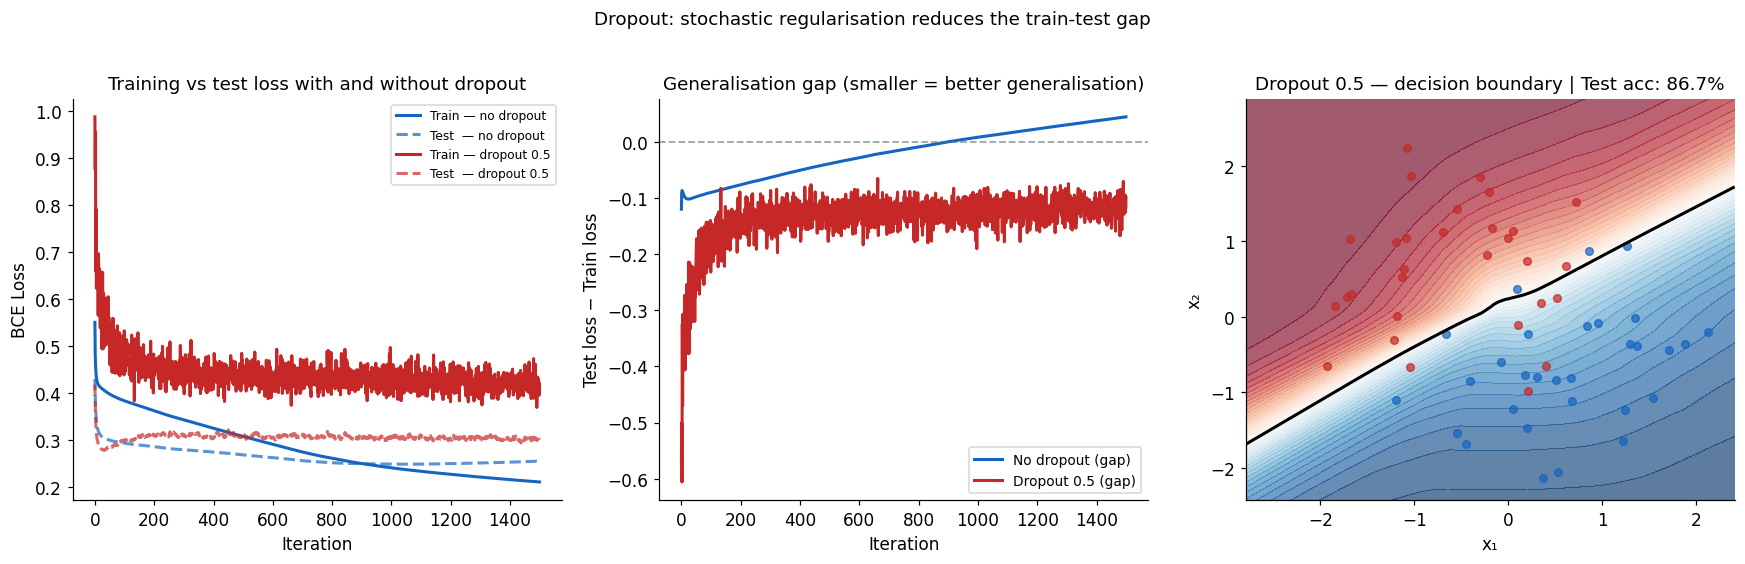

Average generalisation gap (last 100 iters):
  No dropout:      0.0408
  Dropout p=0.5:   -0.1184
  Reduction: 390.1%


In [8]:
# ⚙ IMPLEMENTATION — Dropout layer and training comparison

def dropout_forward(A, p_drop, training=True):
    """
    Inverted dropout.
    A:      activations, shape (batch, neurons)
    p_drop: probability of zeroing a neuron (e.g. 0.5)
    Returns: masked activations, same expected magnitude as input
    """
    if not training or p_drop == 0:
        return A   # no dropout at test time
    mask = (np.random.rand(*A.shape) > p_drop).astype(float)
    return A * mask / (1.0 - p_drop)   # scale to maintain expected value


# Demonstrate: compare training with and without dropout on a small noisy dataset
np.random.seed(SEED)
X_do, y_do = make_moons(n_samples=200, noise=0.35, random_state=SEED)
scaler_do   = StandardScaler()
X_do        = scaler_do.fit_transform(X_do)
X_do_tr, X_do_te, y_do_tr, y_do_te = train_test_split(
    X_do, y_do, test_size=0.3, random_state=SEED, stratify=y_do)

def sigmoid(z): return 1/(1+np.exp(-np.clip(z, -30, 30)))
def relu(z): return np.maximum(0, z)

class SmallNet:
    """3-layer net (2→32→32→1) with optional dropout."""
    def __init__(self, n_hidden=32, p_drop=0.0, seed=SEED):
        np.random.seed(seed)
        s1 = np.sqrt(2/2);  s2 = np.sqrt(2/n_hidden)
        self.W1 = np.random.randn(n_hidden, 2)     * s1
        self.b1 = np.zeros(n_hidden)
        self.W2 = np.random.randn(n_hidden, n_hidden) * s2
        self.b2 = np.zeros(n_hidden)
        self.W3 = np.random.randn(1, n_hidden)     * s2
        self.b3 = np.zeros(1)
        self.p_drop = p_drop

    def forward(self, X, training=True):
        self.X   = X
        self.Z1  = X  @ self.W1.T + self.b1
        self.A1  = relu(self.Z1)
        self.A1d = dropout_forward(self.A1, self.p_drop, training)
        self.Z2  = self.A1d @ self.W2.T + self.b2
        self.A2  = relu(self.Z2)
        self.A2d = dropout_forward(self.A2, self.p_drop, training)
        self.Z3  = self.A2d @ self.W3.T + self.b3
        self.A3  = sigmoid(self.Z3)
        return self.A3.squeeze()

    def train(self, X, y, lr=0.05, iters=1500):
        tr_losses, te_losses = [], []
        for i in range(iters):
            yh = self.forward(X, training=True)
            N  = len(y)
            eps = 1e-12
            loss = -np.mean(y*np.log(yh+eps) + (1-y)*np.log(1-yh+eps))
            tr_losses.append(loss)
            dZ3 = (yh - y)[:,None] / N
            dW3 = dZ3.T @ self.A2d; db3 = dZ3.sum(0)
            dA2 = dZ3 @ self.W3
            dA2 *= (self.A2 > 0)                 # ReLU backward (without dropout for simplicity)
            dZ2 = dA2
            dW2 = dZ2.T @ self.A1d; db2 = dZ2.sum(0)
            dA1 = dZ2 @ self.W2
            dZ1 = dA1 * (self.Z1 > 0)
            dW1 = dZ1.T @ X; db1 = dZ1.sum(0)
            for p, g in [(self.W3,dW3),(self.b3,db3),(self.W2,dW2),
                          (self.b2,db2),(self.W1,dW1),(self.b1,db1)]:
                p -= lr * g
            te_yh  = self.forward(X_do_te, training=False)
            te_loss = -np.mean(y_do_te*np.log(te_yh+eps) + (1-y_do_te)*np.log(1-te_yh+eps))
            te_losses.append(te_loss)
        return tr_losses, te_losses


np.random.seed(SEED)
net_nodrop = SmallNet(n_hidden=64, p_drop=0.0)
np.random.seed(SEED)
net_drop   = SmallNet(n_hidden=64, p_drop=0.5)

tr_no, te_no = net_nodrop.train(X_do_tr, y_do_tr, lr=0.05, iters=1500)
tr_dr, te_dr = net_drop.train(X_do_tr, y_do_tr, lr=0.05, iters=1500)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss curves
ax = axes[0]
ax.plot(tr_no, color=C['blue'],   lw=2, label='Train — no dropout')
ax.plot(te_no, color=C['blue'],   lw=2, ls='--', alpha=0.7, label='Test  — no dropout')
ax.plot(tr_dr, color=C['red'],    lw=2, label='Train — dropout 0.5')
ax.plot(te_dr, color=C['red'],    lw=2, ls='--', alpha=0.7, label='Test  — dropout 0.5')
ax.set_xlabel('Iteration'); ax.set_ylabel('BCE Loss')
ax.set_title('Training vs test loss with and without dropout')
ax.legend(fontsize=8)

# Generalisation gap
gap_no = np.array(te_no) - np.array(tr_no)
gap_dr = np.array(te_dr) - np.array(tr_dr)
ax = axes[1]
ax.plot(gap_no, color=C['blue'], lw=2, label='No dropout (gap)')
ax.plot(gap_dr, color=C['red'],  lw=2, label='Dropout 0.5 (gap)')
hline(ax, 0)
ax.set_xlabel('Iteration'); ax.set_ylabel('Test loss − Train loss')
ax.set_title('Generalisation gap (smaller = better generalisation)')
ax.legend(fontsize=9)

# Decision boundaries
h = 0.04
x_min, x_max = X_do[:,0].min()-0.3, X_do[:,0].max()+0.3
y_min, y_max = X_do[:,1].min()-0.3, X_do[:,1].max()+0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid   = np.c_[xx.ravel(), yy.ravel()]

ax = axes[2]
Z_dr = net_drop.forward(grid, training=False).reshape(xx.shape)
ax.contourf(xx, yy, Z_dr, levels=40, cmap='RdBu', alpha=0.65)
ax.contour(xx, yy, Z_dr, levels=[0.5], colors='k', linewidths=2)
ax.scatter(X_do_te[y_do_te==0,0], X_do_te[y_do_te==0,1], c=C['red'],  s=25, alpha=0.7)
ax.scatter(X_do_te[y_do_te==1,0], X_do_te[y_do_te==1,1], c=C['blue'], s=25, alpha=0.7)
ax.set_title(f'Dropout 0.5 — decision boundary | Test acc: {np.mean((net_drop.forward(X_do_te,False)>0.5)==y_do_te)*100:.1f}%')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

plt.suptitle('Dropout: stochastic regularisation reduces the train-test gap',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

final_gap_no = np.mean(gap_no[-100:])
final_gap_dr = np.mean(gap_dr[-100:])
print(f"Average generalisation gap (last 100 iters):")
print(f"  No dropout:      {final_gap_no:.4f}")
print(f"  Dropout p=0.5:   {final_gap_dr:.4f}")
print(f"  Reduction: {(final_gap_no - final_gap_dr)/final_gap_no * 100:.1f}%")


---
## Section 7 — Early Stopping: Regularisation Through Time

As training continues, a model first reduces both train and validation loss,  
then validation loss begins to **increase** while train loss keeps falling — overfitting.

**Early stopping:** halt training at the epoch with the lowest validation loss.

### Why it works

From a regularisation perspective, early stopping is equivalent to constraining  
the model to a region of parameter space near the initialisation.  
Models near initialisation tend to represent smoother, lower-complexity functions  
(implicit bias of gradient descent toward low-norm solutions).

### Implementation

```python
best_val_loss = inf
patience = 10  # wait this many epochs with no improvement before stopping
no_improve = 0

for epoch in range(max_epochs):
    train(...)
    val_loss = evaluate(val_set)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy(model.weights)
        no_improve    = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            break  # stop training

model.weights = best_weights  # restore best checkpoint
```

In PyTorch this is typically implemented manually or with a scheduler callback.


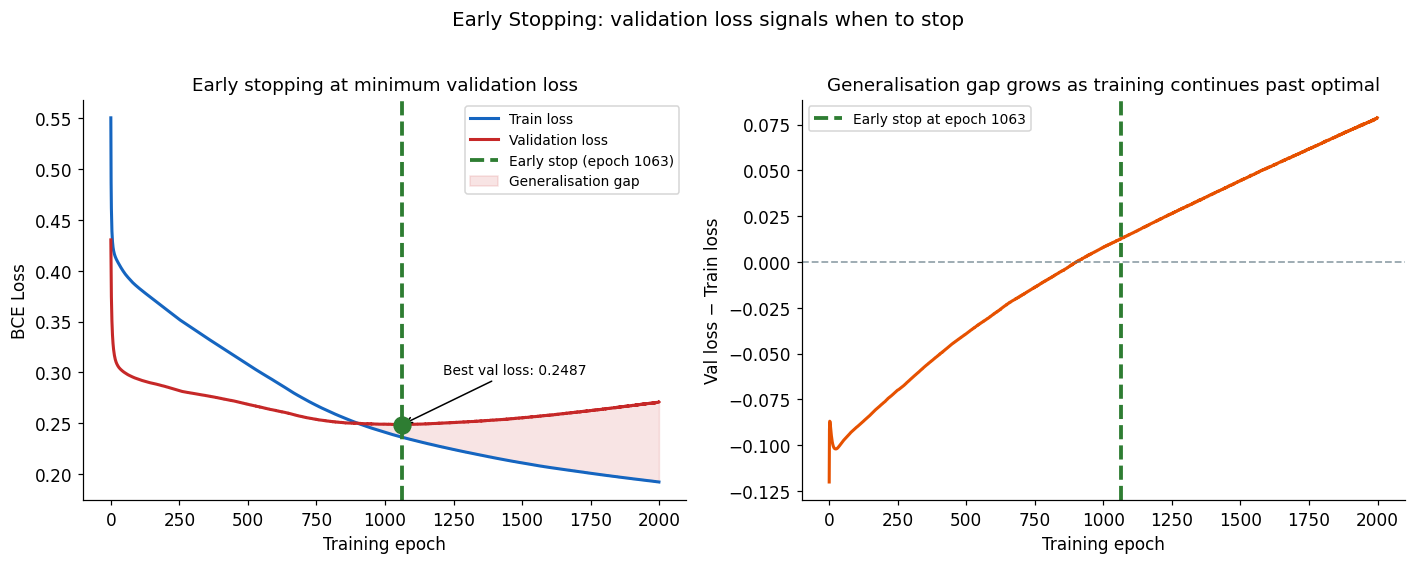

Early stopping epoch: 1063
Train loss at stop:   0.2362
Val   loss at stop:   0.2487
Val   loss at end:    0.2709
Saved by early stopping: 0.0222 val loss units


In [9]:
# 🖼 PLOT — Early stopping visualised on train/val curves

np.random.seed(SEED)
net_es = SmallNet(n_hidden=64, p_drop=0.0)
tr_es, te_es = net_es.train(X_do_tr, y_do_tr, lr=0.05, iters=2000)

best_epoch = np.argmin(te_es)
best_val   = te_es[best_epoch]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(tr_es, color=C['blue'],  lw=2, label='Train loss')
ax.plot(te_es, color=C['red'],   lw=2, label='Validation loss')
ax.axvline(best_epoch, color=C['green'], ls='--', lw=2.5,
           label=f'Early stop (epoch {best_epoch})')
ax.scatter([best_epoch], [best_val], s=120, color=C['green'], zorder=5)
ax.annotate(f'Best val loss: {best_val:.4f}',
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 150, best_val + 0.05),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.fill_between(range(len(te_es)), tr_es, te_es,
                where=[te > tr for te, tr in zip(te_es, tr_es)],
                alpha=0.12, color=C['red'], label='Generalisation gap')
ax.set_xlabel('Training epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Early stopping at minimum validation loss')
ax.legend(fontsize=9)

# Generalisation gap vs epoch
ax = axes[1]
gap_es = np.array(te_es) - np.array(tr_es)
ax.plot(gap_es, color=C['orange'], lw=2)
ax.axvline(best_epoch, color=C['green'], ls='--', lw=2.5,
           label=f'Early stop at epoch {best_epoch}')
hline(ax, 0)
ax.set_xlabel('Training epoch'); ax.set_ylabel('Val loss − Train loss')
ax.set_title('Generalisation gap grows as training continues past optimal')
ax.legend(fontsize=9)

plt.suptitle('Early Stopping: validation loss signals when to stop', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Early stopping epoch: {best_epoch}")
print(f"Train loss at stop:   {tr_es[best_epoch]:.4f}")
print(f"Val   loss at stop:   {te_es[best_epoch]:.4f}")
print(f"Val   loss at end:    {te_es[-1]:.4f}")
print(f"Saved by early stopping: {te_es[-1]-te_es[best_epoch]:.4f} val loss units")


---
## Section 8 — Why Averaging Helps: The Ensemble Effect

### Key result

If we have $M$ models with **identical variance** $\sigma^2$ and **uncorrelated errors**,  
their average has variance $\sigma^2 / M$:

$$\text{Var}\left[\frac{1}{M}\sum_{m=1}^M \hat{f}_m(x)\right]
= \frac{1}{M^2} \sum_{m=1}^M \text{Var}[\hat{f}_m(x)] = \frac{\sigma^2}{M}$$

**Averaging $M$ models reduces variance by a factor of $M$, while leaving bias unchanged.**

### The catch: correlation

In practice, models trained on the same data are correlated.  
If correlation coefficient is $\rho$:

$$\text{Var}[\text{ensemble}] = \rho \sigma^2 + \frac{1-\rho}{M} \sigma^2$$

As $M \to \infty$, this approaches $\rho \sigma^2$ — the irreducible correlation floor.  
**The key to good ensembles is diversity among models.**

Bagging and boosting are two strategies to create diverse models deliberately.


   M (ensemble size)      Variance     Theory σ²/M     Ratio
--------------------------------------------------------------
  M=  1                    0.24731         0.24731     1.000
  M=  2                    0.12120         0.12365     0.980
  M=  5                    0.04728         0.04946     0.956
  M= 10                    0.02244         0.02473     0.907
  M= 20                    0.00966         0.01237     0.781
  M= 50                    0.00226         0.00495     0.458

Ratio ≈ 1.0 confirms: ensemble variance = σ²/M when errors are independent.


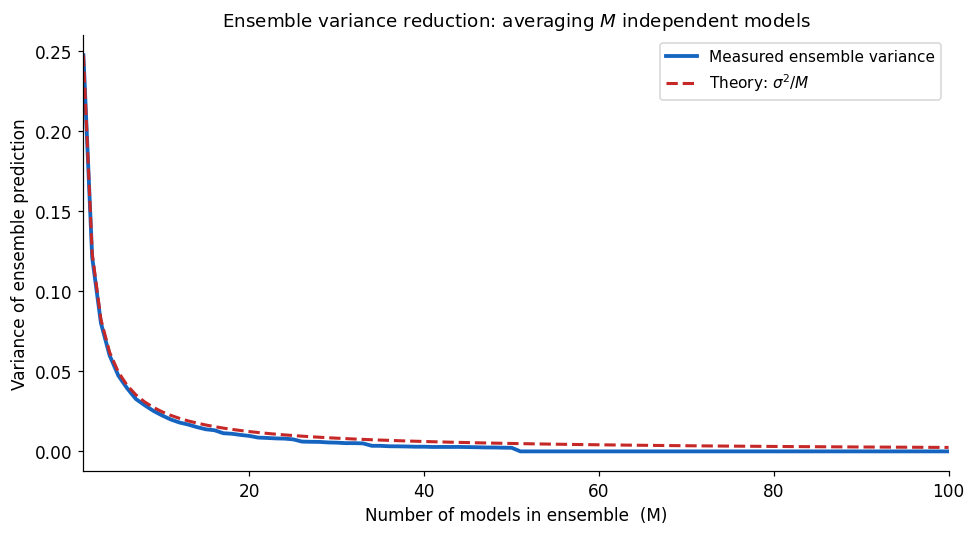

In [10]:
# 🔍 DERIVATION — Verify ensemble variance reduction numerically

np.random.seed(SEED)
M_values  = [1, 2, 5, 10, 20, 50]
n_samples = 500
x_ens     = np.random.uniform(-2, 2, n_samples)
y_ens     = true_function(x_ens)

def noisy_predictor(x, seed):
    """A predictor with noise: truth + Gaussian noise."""
    np.random.seed(seed)
    return true_function(x) + np.random.randn(len(x)) * 0.5

# Collect 100 individual noisy predictions
n_models = 100
all_preds = np.array([noisy_predictor(x_ens, s) for s in range(n_models)])

print(f"{'M (ensemble size)':>20}  {'Variance':>12}  {'Theory σ²/M':>14}  {'Ratio':>8}")
print("-" * 62)
sigma2_single = np.var(all_preds, axis=0).mean()
for M in M_values:
    # Average over M models for n_models//M ensembles
    n_ens = n_models // M
    ens_preds = np.array([all_preds[i*M:(i+1)*M].mean(axis=0)
                           for i in range(n_ens)])
    ens_var = np.var(ens_preds, axis=0).mean()
    theory  = sigma2_single / M
    print(f"  M={M:>3}               {ens_var:>12.5f}  {theory:>14.5f}  {ens_var/theory:>8.3f}")

print()
print("Ratio ≈ 1.0 confirms: ensemble variance = σ²/M when errors are independent.")

# ── Plot variance reduction ───────────────────────────────────────────────────
M_fine = np.arange(1, 101)
measured_vars = []
for M in M_fine:
    n_ens_f = max(1, n_models // M)
    ep = np.array([all_preds[:n_ens_f*M].reshape(n_ens_f, M, -1).mean(axis=1)
                    for _ in [1]])[0]
    measured_vars.append(np.var(ep, axis=0).mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(M_fine, measured_vars, color=C['blue'], lw=2.5, label='Measured ensemble variance')
ax.plot(M_fine, sigma2_single / M_fine, color=C['red'], ls='--', lw=2,
        label=r'Theory: $\sigma^2 / M$')
ax.set_xlabel('Number of models in ensemble  (M)')
ax.set_ylabel('Variance of ensemble prediction')
ax.set_title('Ensemble variance reduction: averaging $M$ independent models')
ax.legend(fontsize=10)
ax.set_xlim(1, 100)
plt.tight_layout()
plt.show()


---
## Section 9 — Bagging: Bootstrap Aggregating

**Bagging** (Breiman, 1996) creates diverse models by training each one on a  
**bootstrap sample** — a dataset of size $N$ drawn **with replacement** from the training set.

### The bootstrap

Each bootstrap sample:
- Has the same size $N$ as the original
- Each example is drawn independently with replacement
- On average, each sample includes $\approx 63.2\%$ of original examples  
  (the rest, $\approx 36.8\%$, are **out-of-bag** — useful for free validation)

The probability that a specific example is **not** selected in a sample of size $N$:

$$\left(1 - \frac{1}{N}\right)^N \xrightarrow{N\to\infty} e^{-1} \approx 0.368$$

### The algorithm

```
For m = 1 to M:
    Sample D_m ~ Bootstrap(D_train)   # with replacement
    Train model f_m on D_m

Predict: ŷ = majority_vote(f_1(x), ..., f_M(x))   # classification
       or ŷ = mean(f_1(x), ..., f_M(x))            # regression
```

### Why bagging reduces variance

Each $D_m$ is a different perturbation of the training set.  
Models trained on different $D_m$ are **diverse** — they make different errors.  
Averaging those diverse errors regresses to the true signal.

**Bagging helps high-variance models** (deep trees, neural networks).  
It does **not** reduce bias — a biased model averaged with itself is still biased.

Random Forests are the canonical application: bagging of decision trees,  
with additional feature randomness at each split.


In [11]:
# ⚙ IMPLEMENTATION — Bagging from scratch

class BaggingClassifier:
    """
    Bagging over decision trees — implemented from first principles.
    """

    def __init__(self, n_estimators=50, max_depth=None, seed=SEED):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.seed         = seed
        self.estimators   = []
        self.oob_indices  = []

    def fit(self, X, y):
        np.random.seed(self.seed)
        N = len(y)
        self.estimators   = []
        self.oob_indices  = []

        for m in range(self.n_estimators):
            # Bootstrap sample
            idx_boot = np.random.choice(N, N, replace=True)
            idx_oob  = np.setdiff1d(np.arange(N), idx_boot)
            X_boot, y_boot = X[idx_boot], y[idx_boot]

            # Train a single decision tree
            tree = DecisionTreeClassifier(max_depth=self.max_depth,
                                          random_state=self.seed + m)
            tree.fit(X_boot, y_boot)
            self.estimators.append(tree)
            self.oob_indices.append(idx_oob)
        return self

    def predict_proba(self, X):
        probs = np.array([est.predict_proba(X)[:, 1]
                          for est in self.estimators])
        return probs.mean(axis=0)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def oob_score(self, X, y):
        """Out-of-bag estimate — free validation from bootstrap."""
        N    = len(y)
        oob_pred = np.zeros(N)
        oob_cnt  = np.zeros(N)
        for tree, idx_oob in zip(self.estimators, self.oob_indices):
            if len(idx_oob) == 0: continue
            preds = tree.predict(X[idx_oob])
            oob_pred[idx_oob] += preds
            oob_cnt[idx_oob]  += 1
        valid  = oob_cnt > 0
        final  = (oob_pred[valid] / oob_cnt[valid] >= 0.5).astype(int)
        return accuracy_score(y[valid], final)


# ── Dataset and evaluation ────────────────────────────────────────────────────
np.random.seed(SEED)
X_bag, y_bag = make_moons(n_samples=400, noise=0.30, random_state=SEED)
scaler_bag   = StandardScaler()
X_bag        = scaler_bag.fit_transform(X_bag)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bag, y_bag, test_size=0.3, stratify=y_bag, random_state=SEED)

# Compare single tree vs bagging at various depths
depths = [1, 3, 5, None]
n_ests = 50

print(f"{'Model':<30} {'Train acc':>10} {'Test acc':>10} {'OOB acc':>10}")
print("-" * 63)
results_bag = {}
for depth in depths:
    dstr = str(depth) if depth else 'full'

    # Single tree
    single = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
    single.fit(X_tr_b, y_tr_b)
    tr_a = accuracy_score(y_tr_b, single.predict(X_tr_b))
    te_a = accuracy_score(y_te_b, single.predict(X_te_b))
    print(f"  Single tree (depth={dstr:<4}) {tr_a:>10.3f} {te_a:>10.3f}       ---")

    # Bagging
    bag = BaggingClassifier(n_estimators=n_ests, max_depth=depth)
    bag.fit(X_tr_b, y_tr_b)
    tr_b = accuracy_score(y_tr_b, bag.predict(X_tr_b))
    te_b = accuracy_score(y_te_b, bag.predict(X_te_b))
    oob  = bag.oob_score(X_tr_b, y_tr_b)
    print(f"  Bagging     (depth={dstr:<4}) {tr_b:>10.3f} {te_b:>10.3f} {oob:>10.3f}")
    results_bag[(depth, 'bag')] = (tr_b, te_b, bag)
    print()


Model                           Train acc   Test acc    OOB acc
---------------------------------------------------------------
  Single tree (depth=1   )      0.782      0.842       ---
  Bagging     (depth=1   )      0.786      0.842      0.754

  Single tree (depth=3   )      0.879      0.917       ---
  Bagging     (depth=3   )      0.875      0.917      0.839

  Single tree (depth=5   )      0.950      0.883       ---
  Bagging     (depth=5   )      0.954      0.908      0.886

  Single tree (depth=full)      1.000      0.875       ---
  Bagging     (depth=full)      1.000      0.892      0.871



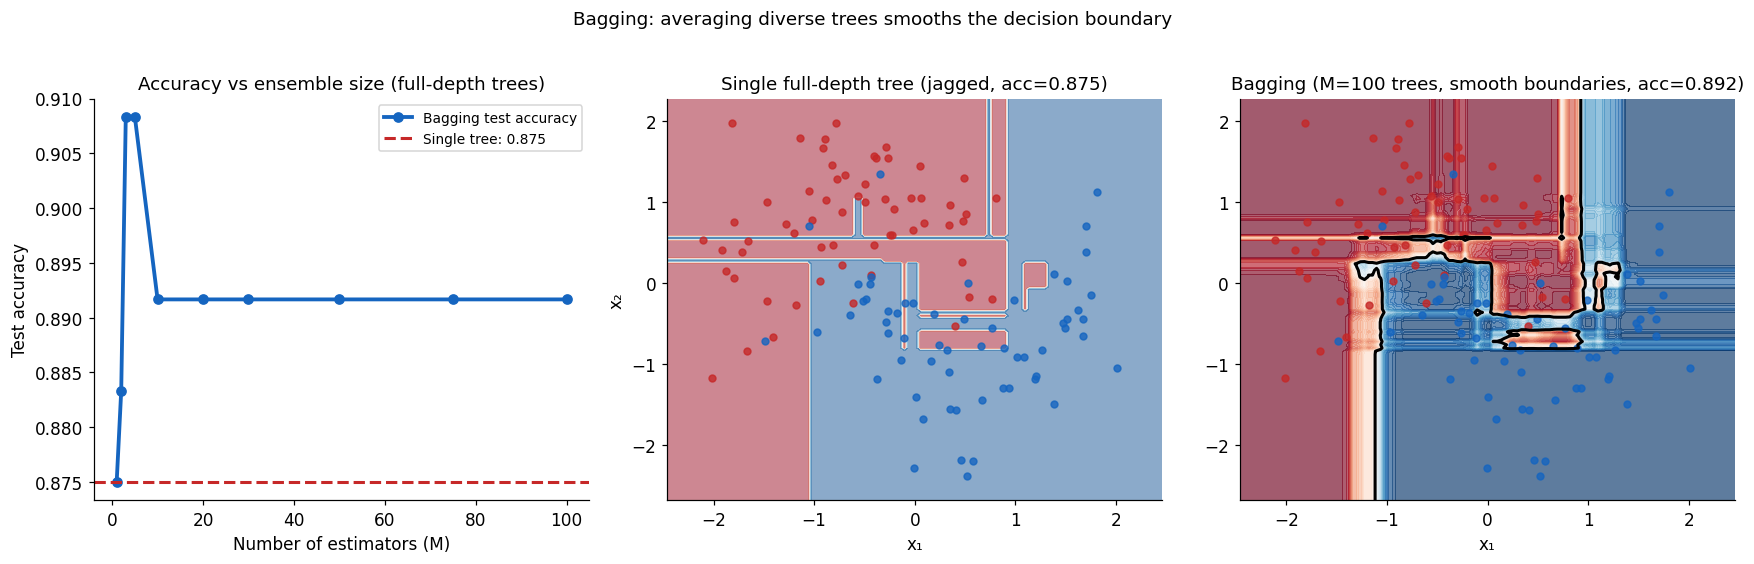

In [12]:
# 🖼 PLOT — Bagging: n_estimators effect and decision boundaries

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: test accuracy vs n_estimators
n_est_range = [1, 2, 3, 5, 10, 20, 30, 50, 75, 100]
acc_single  = accuracy_score(y_te_b,
                DecisionTreeClassifier(max_depth=None, random_state=SEED)
                .fit(X_tr_b, y_tr_b).predict(X_te_b))

bag_accs = []
for n_est in n_est_range:
    b = BaggingClassifier(n_estimators=n_est, max_depth=None).fit(X_tr_b, y_tr_b)
    bag_accs.append(accuracy_score(y_te_b, b.predict(X_te_b)))

ax = axes[0]
ax.plot(n_est_range, bag_accs, 'o-', color=C['blue'], lw=2.5,
        label='Bagging test accuracy')
ax.axhline(acc_single, color=C['red'], ls='--', lw=2,
           label=f'Single tree: {acc_single:.3f}')
ax.set_xlabel('Number of estimators (M)')
ax.set_ylabel('Test accuracy')
ax.set_title('Accuracy vs ensemble size (full-depth trees)')
ax.legend(fontsize=9)

# Panel 2: decision boundary — single deep tree vs bagging
h_b = 0.04
x0_min, x0_max = X_bag[:,0].min()-0.3, X_bag[:,0].max()+0.3
x1_min, x1_max = X_bag[:,1].min()-0.3, X_bag[:,1].max()+0.3
xx_b, yy_b = np.meshgrid(np.arange(x0_min, x0_max, h_b),
                           np.arange(x1_min, x1_max, h_b))
grid_b = np.c_[xx_b.ravel(), yy_b.ravel()]

single_tree = DecisionTreeClassifier(max_depth=None, random_state=SEED)
single_tree.fit(X_tr_b, y_tr_b)
Z_single = single_tree.predict(grid_b).reshape(xx_b.shape)

ax = axes[1]
ax.contourf(xx_b, yy_b, Z_single, cmap='RdBu', alpha=0.5)
ax.scatter(X_te_b[y_te_b==0,0], X_te_b[y_te_b==0,1], c=C['red'],  s=20, alpha=0.8)
ax.scatter(X_te_b[y_te_b==1,0], X_te_b[y_te_b==1,1], c=C['blue'], s=20, alpha=0.8)
ax.set_title(f'Single full-depth tree (jagged, acc={acc_single:.3f})')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

# Panel 3: bagging boundary
bag_full = BaggingClassifier(n_estimators=100, max_depth=None)
bag_full.fit(X_tr_b, y_tr_b)
Z_bag = bag_full.predict_proba(grid_b).reshape(xx_b.shape)
acc_bag = accuracy_score(y_te_b, bag_full.predict(X_te_b))

ax = axes[2]
ax.contourf(xx_b, yy_b, Z_bag, levels=40, cmap='RdBu', alpha=0.65)
ax.contour( xx_b, yy_b, Z_bag, levels=[0.5], colors='k', linewidths=2)
ax.scatter(X_te_b[y_te_b==0,0], X_te_b[y_te_b==0,1], c=C['red'],  s=20, alpha=0.8)
ax.scatter(X_te_b[y_te_b==1,0], X_te_b[y_te_b==1,1], c=C['blue'], s=20, alpha=0.8)
ax.set_title(f'Bagging (M=100 trees, smooth boundaries, acc={acc_bag:.3f})')
ax.set_xlabel('x₁')

plt.suptitle('Bagging: averaging diverse trees smooths the decision boundary',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 10 — Boosting: AdaBoost Derived from First Principles

**Boosting** builds an ensemble **sequentially**: each model focuses on the examples  
that previous models got wrong.

### AdaBoost (Freund & Schapire, 1997)

Maintain a weight $w_i$ for each training example.  
Initially all weights are equal: $w_i = 1/N$.

For $m = 1, \ldots, M$:

1. Train a weak learner $h_m$ on the **weighted** training set
2. Compute weighted error: $\epsilon_m = \sum_{i: h_m(x_i) \neq y_i} w_i$
3. Compute model weight: $\alpha_m = \frac{1}{2}\ln\frac{1 - \epsilon_m}{\epsilon_m}$
4. Update example weights:

$$w_i \leftarrow w_i \cdot \exp(-\alpha_m y_i h_m(x_i))$$

Then normalise so $\sum_i w_i = 1$.

5. Final prediction: $H(x) = \text{sign}\left(\sum_{m=1}^M \alpha_m h_m(x)\right)$

### Intuition for $\alpha_m$

- If $\epsilon_m = 0.5$ (random guessing), $\alpha_m = 0$ — this model contributes nothing
- If $\epsilon_m \to 0$ (perfect), $\alpha_m \to +\infty$ — this model dominates
- If $\epsilon_m > 0.5$ (worse than random), $\alpha_m < 0$ — flip this model's predictions

### Why boosting works: exponential loss minimisation

AdaBoost minimises the **exponential loss** $\sum_i e^{-y_i F(x_i)}$  
where $F(x) = \sum_m \alpha_m h_m(x)$ is the additive model.  
Each round of boosting takes a coordinate descent step on this loss.


In [13]:
# ⚙ IMPLEMENTATION — AdaBoost from scratch

class AdaBoost:
    """
    AdaBoost with decision stumps (max_depth=1 trees).
    Every line corresponds directly to the algorithm in the derivation above.
    """

    def __init__(self, n_estimators=50, seed=SEED):
        self.n_estimators = n_estimators
        self.seed         = seed
        self.estimators   = []
        self.alphas       = []
        self.train_errors = []
        self.weights_history = []

    def fit(self, X, y):
        """y must be in {-1, +1} for AdaBoost."""
        N = len(y)
        w = np.ones(N) / N            # Step 0: uniform weights

        self.estimators = []; self.alphas = []
        self.train_errors = []; self.weights_history = []

        for m in range(self.n_estimators):
            self.weights_history.append(w.copy())

            # Step 1: train weighted stump
            stump = DecisionTreeClassifier(max_depth=1,
                                           random_state=self.seed + m)
            stump.fit(X, y, sample_weight=w)

            # Step 2: weighted error
            preds        = stump.predict(X)
            incorrect    = (preds != y).astype(float)
            epsilon_m    = np.dot(w, incorrect)           # weighted error rate
            epsilon_m    = np.clip(epsilon_m, 1e-10, 1 - 1e-10)

            # Step 3: model weight
            alpha_m = 0.5 * np.log((1 - epsilon_m) / epsilon_m)

            # Step 4: update example weights
            w = w * np.exp(-alpha_m * y * preds)
            w = w / w.sum()                               # normalise

            self.estimators.append(stump)
            self.alphas.append(alpha_m)

            # Training error of current ensemble
            H = self.predict(X)
            self.train_errors.append(np.mean(H != (y == 1)))

        return self

    def predict_score(self, X):
        """Raw additive score F(x) = Σ α_m h_m(x)."""
        scores = np.zeros(len(X))
        for alpha, stump in zip(self.alphas, self.estimators):
            scores += alpha * stump.predict(X)
        return scores

    def predict(self, X):
        return (self.predict_score(X) >= 0).astype(int)


# Convert labels to {-1, +1} for AdaBoost
y_ada_tr = 2 * y_tr_b - 1
y_ada_te = 2 * y_te_b - 1

ada = AdaBoost(n_estimators=100, seed=SEED)
ada.fit(X_tr_b, y_ada_tr)

tr_acc = accuracy_score(y_tr_b, ada.predict(X_tr_b))
te_acc = accuracy_score(y_te_b, ada.predict(X_te_b))
print(f"AdaBoost (100 stumps)  Train acc: {tr_acc:.3f}  Test acc: {te_acc:.3f}")
print()
print("Alpha values for first 10 stumps (model confidence weights):")
for i, a in enumerate(ada.alphas[:10]):
    print(f"  Stump {i+1:>2}: alpha = {a:.4f}")


AdaBoost (100 stumps)  Train acc: 0.929  Test acc: 0.867

Alpha values for first 10 stumps (model confidence weights):
  Stump  1: alpha = 0.6391
  Stump  2: alpha = 0.5111
  Stump  3: alpha = 0.4475
  Stump  4: alpha = 0.4961
  Stump  5: alpha = 0.3167
  Stump  6: alpha = 0.2742
  Stump  7: alpha = 0.2762
  Stump  8: alpha = 0.3129
  Stump  9: alpha = 0.2311
  Stump 10: alpha = 0.1252


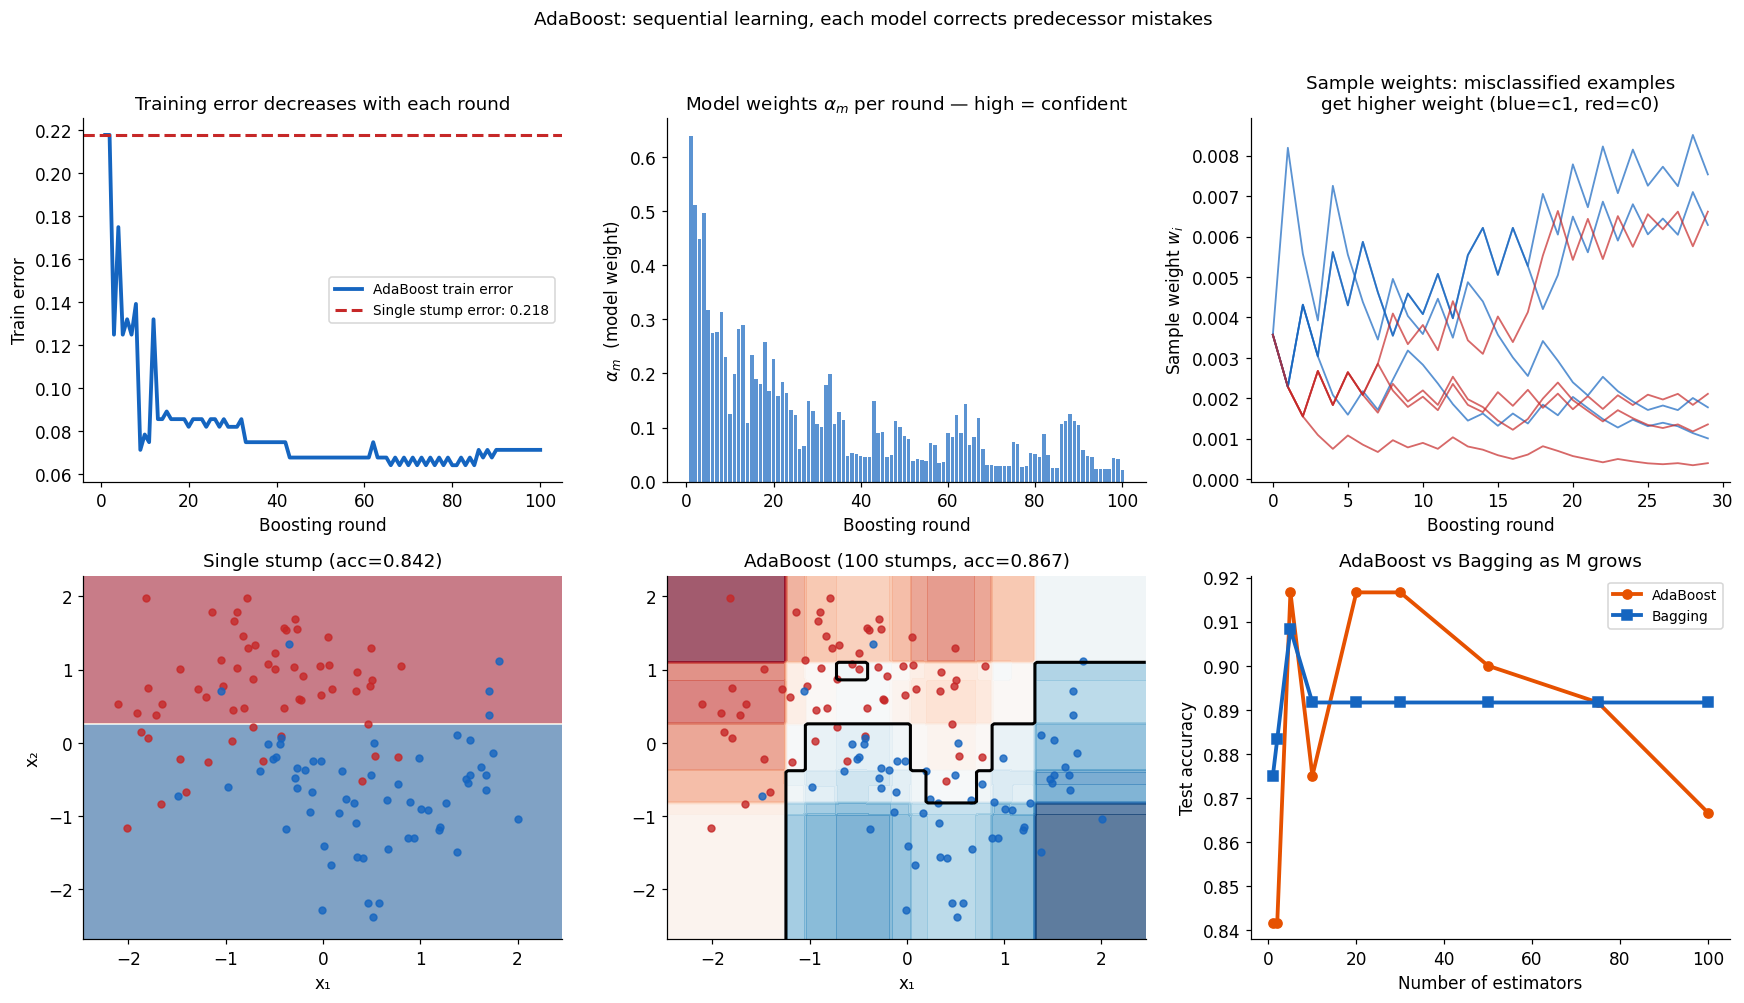

In [14]:
# 🖼 PLOT — AdaBoost: sample weights evolving, alpha values, and accuracy

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Panel 1: training error vs boosting round
ax = axes[0, 0]
ax.plot(range(1, len(ada.train_errors)+1), ada.train_errors,
        color=C['blue'], lw=2.5, label='AdaBoost train error')
acc_stump = 1 - accuracy_score(
    y_tr_b, DecisionTreeClassifier(max_depth=1, random_state=SEED)
    .fit(X_tr_b, y_tr_b).predict(X_tr_b))
ax.axhline(acc_stump, color=C['red'], ls='--', lw=2,
           label=f'Single stump error: {acc_stump:.3f}')
ax.set_xlabel('Boosting round'); ax.set_ylabel('Train error')
ax.set_title('Training error decreases with each round')
ax.legend(fontsize=9)

# Panel 2: alpha (model weight) per round
ax = axes[0, 1]
ax.bar(range(1, len(ada.alphas)+1), ada.alphas, color=C['blue'], alpha=0.7)
ax.set_xlabel('Boosting round'); ax.set_ylabel(r'$\alpha_m$  (model weight)')
ax.set_title(r'Model weights $\alpha_m$ per round — high = confident')

# Panel 3: sample weight evolution on 20 random examples
ax = axes[0, 2]
n_show  = 20
indices = np.random.choice(len(y_tr_b), n_show, replace=False)
rounds  = list(range(min(30, len(ada.weights_history))))
for idx in indices[:8]:
    wts = [ada.weights_history[r][idx] for r in rounds]
    correct = y_tr_b[idx]
    ax.plot(rounds, wts, lw=1.2, alpha=0.7,
            color=C['blue'] if correct==1 else C['red'])
ax.set_xlabel('Boosting round'); ax.set_ylabel('Sample weight $w_i$')
ax.set_title('Sample weights: misclassified examples\nget higher weight (blue=c1, red=c0)')

# Panel 4: decision boundary comparison
h_a = 0.04
xx_a, yy_a = np.meshgrid(np.arange(x0_min, x0_max, h_a),
                           np.arange(x1_min, x1_max, h_a))
grid_a = np.c_[xx_a.ravel(), yy_a.ravel()]

ax = axes[1, 0]
stump_single = DecisionTreeClassifier(max_depth=1, random_state=SEED)
stump_single.fit(X_tr_b, y_tr_b)
Z_stump = stump_single.predict(grid_a).reshape(xx_a.shape)
ax.contourf(xx_a, yy_a, Z_stump, cmap='RdBu', alpha=0.55)
ax.scatter(X_te_b[y_te_b==0,0], X_te_b[y_te_b==0,1], c=C['red'],  s=20, alpha=0.8)
ax.scatter(X_te_b[y_te_b==1,0], X_te_b[y_te_b==1,1], c=C['blue'], s=20, alpha=0.8)
acc_s = accuracy_score(y_te_b, stump_single.predict(X_te_b))
ax.set_title(f'Single stump (acc={acc_s:.3f})')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

ax = axes[1, 1]
Z_ada = (ada.predict_score(grid_a) >= 0).astype(int).reshape(xx_a.shape)
score_grid = ada.predict_score(grid_a)
# Normalise for colour display
score_norm = (score_grid - score_grid.min()) / ((score_grid.max() - score_grid.min()) + 1e-8)
ax.contourf(xx_a, yy_a, score_norm.reshape(xx_a.shape),
            levels=40, cmap='RdBu', alpha=0.65)
ax.contour(xx_a, yy_a, Z_ada, levels=[0.5], colors='k', linewidths=2)
ax.scatter(X_te_b[y_te_b==0,0], X_te_b[y_te_b==0,1], c=C['red'],  s=20, alpha=0.8)
ax.scatter(X_te_b[y_te_b==1,0], X_te_b[y_te_b==1,1], c=C['blue'], s=20, alpha=0.8)
ax.set_title(f'AdaBoost (100 stumps, acc={te_acc:.3f})')
ax.set_xlabel('x₁')

# Panel 6: accuracy vs n_estimators for AdaBoost vs Bagging
n_ests_cmp = [1, 2, 5, 10, 20, 30, 50, 75, 100]
ada_accs, bag_accs_cmp = [], []
for n_est in n_ests_cmp:
    a = AdaBoost(n_estimators=n_est).fit(X_tr_b, y_ada_tr)
    ada_accs.append(accuracy_score(y_te_b, a.predict(X_te_b)))
    b = BaggingClassifier(n_estimators=n_est).fit(X_tr_b, y_tr_b)
    bag_accs_cmp.append(accuracy_score(y_te_b, b.predict(X_te_b)))

ax = axes[1, 2]
ax.plot(n_ests_cmp, ada_accs, 'o-', color=C['orange'], lw=2.5, label='AdaBoost')
ax.plot(n_ests_cmp, bag_accs_cmp, 's-', color=C['blue'], lw=2.5, label='Bagging')
ax.set_xlabel('Number of estimators'); ax.set_ylabel('Test accuracy')
ax.set_title('AdaBoost vs Bagging as M grows')
ax.legend(fontsize=9)

plt.suptitle('AdaBoost: sequential learning, each model corrects predecessor mistakes',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


---
## Section 11 — Bagging vs Boosting: When to Use Which

| Property | Bagging | Boosting |
|----------|---------|---------|
| **Training** | Parallel (independent) | Sequential (dependent) |
| **Goal** | Reduce **variance** | Reduce **bias** |
| **Base learners** | High-variance models (deep trees) | Weak learners (stumps) |
| **Sensitivity to noise** | Robust | Sensitive — noisy labels hurt |
| **Overfitting risk** | Low | Can overfit with too many rounds |
| **Interpretability** | Low | Very low |
| **Speed** | Parallelisable | Sequential |
| **Common implementations** | Random Forest | AdaBoost, XGBoost, LightGBM |

### For industrial defect detection

Bagging (Random Forest) is usually the better starting point because:
1. Defect datasets are small — labels can be noisy or borderline
2. Boosting is more sensitive to mislabelled data
3. Random Forest provides built-in feature importance and OOB error estimates
4. XGBoost/LightGBM are worth trying after you have a clean baseline

However, your ResNet-18 is already a high-capacity model.  
Ensembling at the network level (test-time augmentation, snapshot ensembles)  
is more common in practice than training multiple full models.


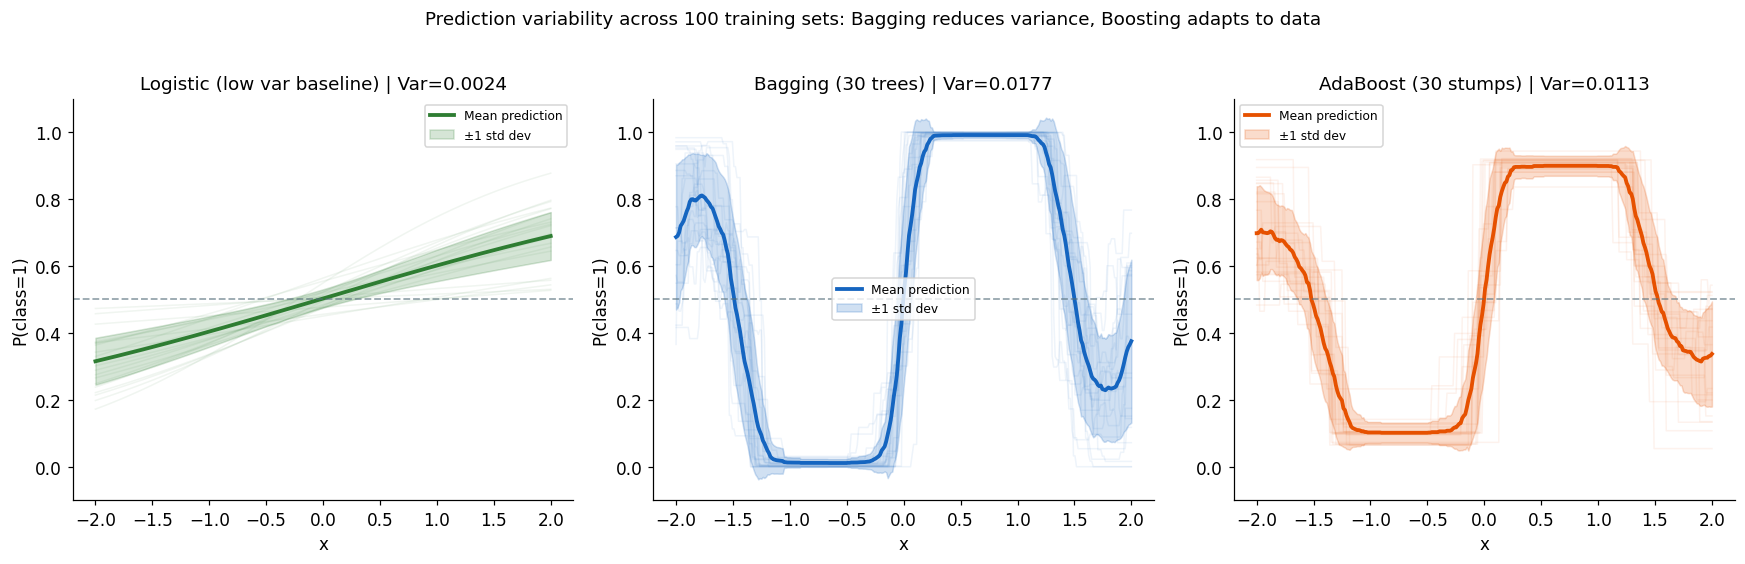

In [15]:
# 🖼 PLOT — Bias vs Variance: Bagging vs Boosting comparison

# Run both over many trials with different training sets
np.random.seed(SEED)
n_trials_cmp = 100
n_tr_cmp = 150

x_test_cmp   = np.linspace(-2, 2, 300)
f_true_cmp   = true_function(x_test_cmp)

bag_preds_all = []
ada_preds_all = []
lr_preds_all  = []

for trial in range(n_trials_cmp):
    x_tr_c = np.random.uniform(-2, 2, n_tr_cmp)
    y_tr_c = true_function(x_tr_c) + np.random.randn(n_tr_cmp) * noise_std
    y_tr_bin = (y_tr_c > y_tr_c.mean()).astype(int)
    y_tr_ada = 2 * y_tr_bin - 1

    # Bagging (regression — average predictions)
    bag_regs = []
    for m in range(30):
        idx = np.random.choice(n_tr_cmp, n_tr_cmp, replace=True)
        tree = DecisionTreeClassifier(max_depth=3, random_state=trial*100+m)
        tree.fit(x_tr_c[idx].reshape(-1,1), y_tr_bin[idx])
        bag_regs.append(tree.predict_proba(x_test_cmp.reshape(-1,1))[:,1])
    bag_preds_all.append(np.array(bag_regs).mean(axis=0))

    # Simple logistic (low variance baseline)
    lr_c = SKLearnLR(max_iter=500, C=1.0)
    lr_c.fit(x_tr_c.reshape(-1,1), y_tr_bin)
    lr_preds_all.append(lr_c.predict_proba(x_test_cmp.reshape(-1,1))[:,1])

    # AdaBoost
    ada_c = AdaBoost(n_estimators=30, seed=trial)
    ada_c.fit(x_tr_c.reshape(-1,1), y_tr_ada)
    raw_score = ada_c.predict_score(x_test_cmp.reshape(-1,1))
    ada_preds_all.append(1/(1+np.exp(-raw_score)))  # sigmoid for probability

bag_arr = np.array(bag_preds_all)
ada_arr = np.array(ada_preds_all)
lr_arr  = np.array(lr_preds_all)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_data = [
    ('Logistic (low var baseline)', lr_arr,  C['green']),
    ('Bagging (30 trees)',          bag_arr, C['blue']),
    ('AdaBoost (30 stumps)',        ada_arr, C['orange']),
]

for ax, (label, arr, col) in zip(axes, labels_data):
    mean_pred = arr.mean(axis=0)
    std_pred  = arr.std(axis=0)

    for i in range(min(20, len(arr))):
        ax.plot(x_test_cmp, arr[i], color=col, alpha=0.07, lw=1)

    ax.plot(x_test_cmp, mean_pred, color=col, lw=2.5, label='Mean prediction')
    ax.fill_between(x_test_cmp, mean_pred - std_pred, mean_pred + std_pred,
                    color=col, alpha=0.2, label='±1 std dev')

    bias2 = np.mean((mean_pred - 0.5)**2)  # approximate
    var   = np.mean(np.var(arr, axis=0))
    ax.set_title(f'{label} | Var={var:.4f}')
    ax.set_ylim(-0.1, 1.1)
    hline(ax, 0.5)
    ax.set_xlabel('x'); ax.set_ylabel('P(class=1)')
    ax.legend(fontsize=8)

plt.suptitle('Prediction variability across 100 training sets: '
             'Bagging reduces variance, Boosting adapts to data',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 12 — Regularisation Strategy for Industrial Defect Detection

### The problem profile

| Factor | Implication |
|--------|------------|
| Small dataset (100–500 images per class) | High variance risk — regularise aggressively |
| Class imbalance (defects are rare) | Standard accuracy is misleading — use F1/recall |
| Noisy labels (borderline defects) | L1/Dropout preferred over boosting |
| Pretrained backbone (ResNet-18) | Most parameters already regularised by pretraining |
| Fine-tuning only final layers | Lower regularisation need than training from scratch |

### Recommended regularisation stack for ResNet-18 fine-tuning

```python
# 1. Weight decay (L2) on all parameters except batch norm
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4    # λ in our derivation
)

# 2. Dropout before the final classifier
self.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(512, n_classes)
)

# 3. Early stopping with patience=10 on validation F1
# 4. Data augmentation — reduces effective variance by diversifying training set
```

### The generalisation checklist before submitting a model

1. **Is train acc >> val acc?** → overfit → add dropout / reduce depth / add data  
2. **Is both train and val acc low?** → underfit → bigger model / fewer constraints  
3. **Does val acc vary a lot across runs?** → high variance → regularise more / ensemble  
4. **Did you normalise using only training stats?** → if no, fix data leakage immediately  
5. **Did you split by production batch, not randomly?** → if no, test performance is optimistic


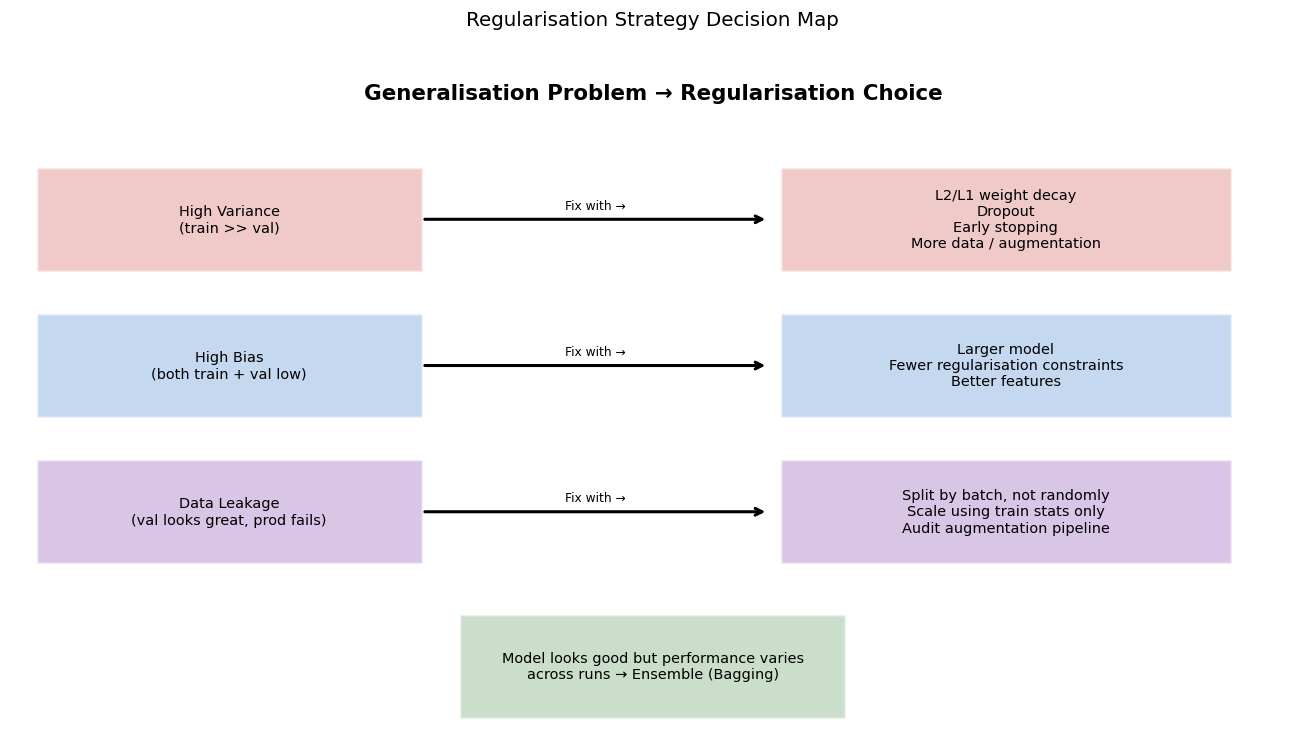

Summary table:

Problem                        Primary tool              Secondary tool
---------------------------------------------------------------------------
  Overfit (high variance)        Dropout / L2 decay        Early stopping, more data
  Underfit (high bias)           Bigger model              Less regularisation
  Small dataset                  Pretrained backbone       Aggressive augmentation
  Noisy labels                   Label smoothing           Bagging (not boosting)
  Feature selection needed       L1 regularisation         Permutation importance
  Variance across runs           Bagging / ensembles       Test-time augmentation


In [16]:
# 🖼 PLOT — Final summary: regularisation decision map

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 8)

# Title
ax.text(5, 7.5, 'Generalisation Problem → Regularisation Choice',
        ha='center', fontsize=14, fontweight='bold')

# Boxes
boxes = [
    # (x, y, width, height, text, color)
    (0.2,  5.5, 3.0, 1.2, 'High Variance\n(train >> val)', C['red']),
    (0.2,  3.8, 3.0, 1.2, 'High Bias\n(both train + val low)', C['blue']),
    (0.2,  2.1, 3.0, 1.2, 'Data Leakage\n(val looks great, prod fails)', C['purple']),
    (6.0,  5.5, 3.5, 1.2, 'L2/L1 weight decay\nDropout\nEarly stopping\nMore data / augmentation', C['red']),
    (6.0,  3.8, 3.5, 1.2, 'Larger model\nFewer regularisation constraints\nBetter features', C['blue']),
    (6.0,  2.1, 3.5, 1.2, 'Split by batch, not randomly\nScale using train stats only\nAudit augmentation pipeline', C['purple']),
    (3.5,  0.3, 3.0, 1.2, 'Model looks good but performance varies\nacross runs → Ensemble (Bagging)', C['green']),
]

for x, y, w, h, text, col in boxes:
    rect = plt.Rectangle((x, y), w, h, facecolor=col,
                          edgecolor='white', alpha=0.25, lw=2, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=9.5, zorder=3)

# Arrows
for (x1, y1), (x2, y2) in [
    ((3.2, 6.1), (5.9, 6.1)),
    ((3.2, 4.4), (5.9, 4.4)),
    ((3.2, 2.7), (5.9, 2.7)),
]:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text((x1+x2)/2, y1 + 0.12, 'Fix with →',
            ha='center', fontsize=8, color='black')

ax.set_title('Regularisation Strategy Decision Map', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

print("Summary table:")
print()
print(f"{'Problem':<30} {'Primary tool':<25} {'Secondary tool'}")
print("-" * 75)
rows = [
    ("Overfit (high variance)",  "Dropout / L2 decay",  "Early stopping, more data"),
    ("Underfit (high bias)",     "Bigger model",         "Less regularisation"),
    ("Small dataset",            "Pretrained backbone",  "Aggressive augmentation"),
    ("Noisy labels",             "Label smoothing",      "Bagging (not boosting)"),
    ("Feature selection needed", "L1 regularisation",    "Permutation importance"),
    ("Variance across runs",     "Bagging / ensembles",  "Test-time augmentation"),
]
for prob, prim, sec in rows:
    print(f"  {prob:<30} {prim:<25} {sec}")


---
## Summary

### What this notebook derived

| Concept | Key formula |
|---------|-------------|
| Bias-variance decomposition | $\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2$ |
| L2 regularisation gradient | $\nabla_w \mathcal{L}_{\text{reg}} = \nabla_w \mathcal{L}_{\text{data}} + 2\lambda w$ |
| L2 update rule | $w \leftarrow (1 - 2\eta\lambda)w - \eta \nabla \mathcal{L}_{\text{data}}$ |
| Dropout (inverted) | $\tilde{a} = a \cdot m / (1-p)$, $m \sim \text{Bernoulli}(1-p)$ |
| Ensemble variance | $\text{Var}[\bar{f}] = \sigma^2/M$ (uncorrelated models) |
| Bootstrap coverage | $P(\text{not selected}) = (1-1/N)^N \to e^{-1} \approx 0.368$ |
| AdaBoost weight | $\alpha_m = \frac{1}{2}\ln\frac{1-\epsilon_m}{\epsilon_m}$ |
| AdaBoost update | $w_i \leftarrow w_i \exp(-\alpha_m y_i h_m(x_i))$ |

### The three levers of generalisation

```
Generalisation error = Bias² + Variance + Noise

Reduce Bias:      increase model capacity, improve features
Reduce Variance:  regularise (L1/L2/dropout), ensemble, get more data  
Noise floor:      irreducible — improve data quality / labelling
```

### What comes next (Workshop 5)

You now understand **why** models fail to generalise and **what to do about it**.  
Workshop 3 applies these ideas to real defect data:  
loading the NEU/MVTec dataset, choosing a splitting strategy that avoids leakage,  
and plugging a regularised ResNet-18 into a reproducible training pipeline.
